# DNS software releases, DNSSEC adoption, and the CVE record

Three clocks over the same seventeen years:

| Clock | Source | What it dates |
|---|---|---|
| **RFC** | IETF publication dates | when a mechanism became a standard |
| **Code** | git tags of 8 implementations, 1,083 stable releases | when a signer could publish it, or a validator check it |
| **Zones** | OpenINTEL forward TLDs + RIR reverse delegations | when anyone actually did |

The question underneath: almost no operator implements DNSSEC themselves, so is
adoption a story about **software updates** rather than about operators reading
RFCs? This notebook draws every figure the three datasets support and lets the
shape of them answer.

**The headline, up front.** Code lag is near zero and deployment lag is years.
Four of four releases that first made a value publishable are followed by
*exactly* zero change in its share a year later. Whatever moves adoption, it is
not the feature becoming available.

Sources: `docs/software_crossref.md`, `docs/releases_vs_adoption.md`,
`docs/cve_crossref.md`.

## 1. Setup, palette and provenance

Colors are the validated reference palette used across this project's reporting:
categorical slots 1-3 (blue, orange, aqua), a single-hue blue ramp for ordered
magnitude, and status red reserved for emphasis. Slots are assigned in fixed
order and never cycled; where more than three categories exist the chart facets
or folds the tail into "other" rather than inventing a fourth hue.

In [1]:
import collections
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter, MaxNLocator

# Walk up so the notebook runs from notebooks/, the repo root, or elsewhere.
ROOT = Path.cwd()
while not (ROOT / "data" / "rfc_checklists").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("run this notebook from inside the rfc_adoption repository")
    ROOT = ROOT.parent
print("repository root:", ROOT)

FIGDIR = ROOT / "reporting" / "charts" / "software"
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- palette (validated reference instance, light mode) --------------------- #
SURFACE = "#fcfcfb"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"      # categorical, fixed order
RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#2a78d6", "#1c5cab", "#104281"]
CRITICAL = "#d03b3b"                               # status, never a series color

plt.rcParams.update({
    "font.family": ["DejaVu Sans", "sans-serif"],
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "text.color": INK,
    "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "axes.titlesize": 13,
    "figure.dpi": 110,
})


def style(ax, axis="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.tick_params(length=0)


def pct(ax, axis="y"):
    fmt = FuncFormatter(lambda v, _: f"{v:g}%")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


def title(ax, headline, sub=None):
    '''Headline plus an optional deck line, without the two overlapping.'''
    ax.set_title(headline, loc="left", color=INK, fontweight="bold",
                 pad=30 if sub else 8)
    if sub:
        ax.text(0, 1.028, sub, transform=ax.transAxes, color=INK_2, fontsize=10,
                va="bottom")


def metric(ax, text):
    '''One line under the axis saying what the number on it actually is.

    Every chart here plots a derived quantity -- a lag, a share, a rate. Without
    the definition on the chart the reader is guessing at the units.
    '''
    ax.text(0, -0.30, text, transform=ax.transAxes, color=MUTED, fontsize=9.5,
            va="top", ha="left", wrap=True)


def year_axis(ax):
    '''Integer year ticks on a fractional-year axis.

    Formatting fractional years with int() alone prints 2021 twice, once for
    2021.0 and once for 2021.5, which reads as a broken axis.
    '''
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, v_=None: f"{int(v)}"))


def save(fig, name):
    path = FIGDIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", pad_inches=0.3)
    plt.show()
    return path

repository root: /mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption


In [2]:
A = json.loads((ROOT / "out/analysis/software_crossref.json").read_text(encoding="utf-8"))
RA = json.loads((ROOT / "out/analysis/release_vs_adoption.json").read_text(encoding="utf-8"))
CV = json.loads((ROOT / "out/analysis/cve_crossref.json").read_text(encoding="utf-8"))
CA = json.loads((ROOT / "out/analysis/cve_adoption_crossref.json").read_text(encoding="utf-8"))
SUP = json.loads((ROOT / "data/software/software_support.json").read_text(encoding="utf-8"))
REL = json.loads((ROOT / "data/software/release_dates.json").read_text(encoding="utf-8"))
AM = json.loads((ROOT / "out/analysis/adoption_measures.json").read_text(encoding="utf-8"))

SRV = pd.read_parquet(ROOT / "out/server_run/timeline_monthly.parquet")
PAN = pd.read_parquet(ROOT / "out/panel_run/timeline_monthly.parquet")
PANEL_SOURCE = "_pooled-afrinic-arin"

NAME = {"unbound": "Unbound", "nsd": "NSD", "bind9": "BIND 9", "knot": "Knot DNS",
        "kresd": "Knot Resolver", "opendnssec": "OpenDNSSEC",
        "pdns-auth": "PowerDNS Auth", "pdns-rec": "PowerDNS Recursor"}


def share(df, basis, dim, values, source=None):
    '''P(value | signed) per month. An absent month is 0%, never missing --
    dropping those deletes the whole pre-release period an event study needs.'''
    b = df[(df.basis == basis) & (df.dimension == dim)]
    if source is not None:
        b = b[b.source == source]
    den = b[b.value == "_total"].groupby("month").domains_peak.sum().sort_index()
    num = (b[b.value.isin(values)].groupby("month").domains_peak.sum()
           .reindex(den.index, fill_value=0))
    return (num / den * 100).sort_index()


def to_year(m):
    return int(m[:4]) + (int(m[5:7]) - 1) / 12

print(f"{len(A['onset_decomposition'])} observables, "
      f"{sum(len(v['releases']) for v in REL.values())} stable releases, "
      f"{CV['totals']['distinct_cves']} CVEs")

5 observables, 1083 stable releases, 441 CVEs


## 2. The three clocks

### 2.1 Onset splits into code lag and deployment lag

`onset` is the time from RFC publication to the first zone publishing the value.
It bundles two very different waits: for somebody to write the code, and for
somebody to switch it on. Split, they are not close in size.

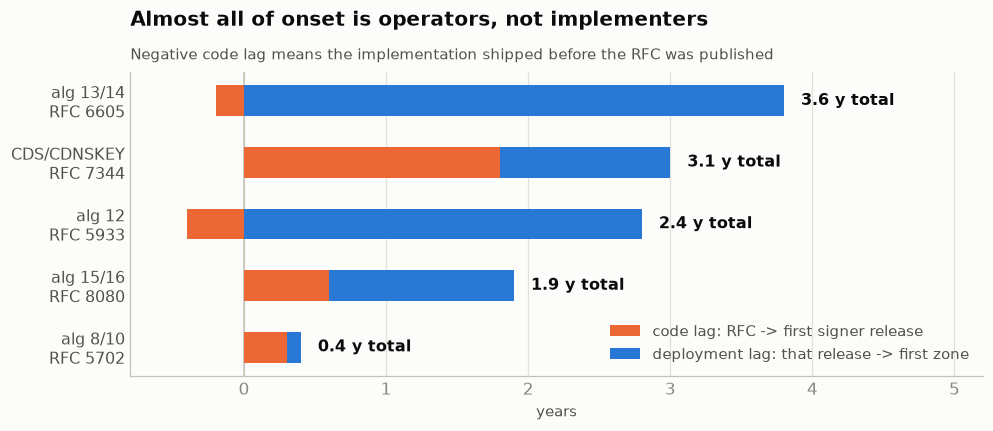

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/01_onset_decomposition.png')

In [3]:
rows = [r for r in A["onset_decomposition"]
        if r.get("code_lag_years") is not None and r.get("deployment_lag_years") is not None]
rows.sort(key=lambda r: r["onset_years"])
labels = [f'{r["observable"]}\n{r["rfc"]}' for r in rows]
code_l = [r["code_lag_years"] for r in rows]
depl = [r["deployment_lag_years"] for r in rows]
y = range(len(rows))

fig, ax = plt.subplots(figsize=(10, 3.6))
# Code lag can be negative (shipped from the draft), so it is drawn from zero and
# deployment stacks from wherever code ended.
ax.barh(y, code_l, height=0.5, color=S2, label="code lag: RFC -> first signer release",
        zorder=3)
ax.barh(y, depl, left=[max(c, 0) for c in code_l], height=0.5, color=S1,
        label="deployment lag: that release -> first zone", zorder=3)
for i, r in enumerate(rows):
    ax.text(max(r["code_lag_years"], 0) + r["deployment_lag_years"] + 0.12, i,
            f'{r["onset_years"]:.1f} y total', va="center", color=INK, fontsize=10.5,
            fontweight="bold")
ax.axvline(0, color=BASELINE, linewidth=1)
ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=10.5, color=INK_2)
ax.set_xlabel("years", color=INK_2)
ax.set_xlim(-0.8, 5.2)
style(ax, axis="x")
ax.legend(frameon=False, loc="lower right", fontsize=10, labelcolor=INK_2)
title(ax, "Almost all of onset is operators, not implementers",
      "Negative code lag means the implementation shipped before the RFC was published")
save(fig, "01_onset_decomposition")

### 2.2 The same thing as a timeline

One row per observable. The gap that matters is the one on the right.

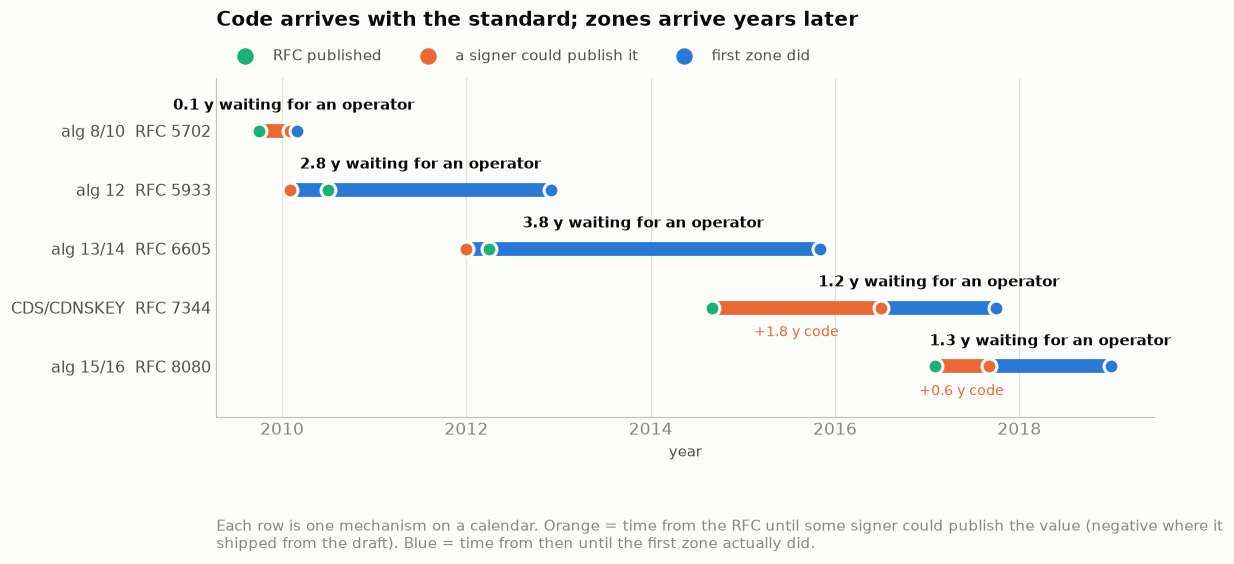

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/02_three_clocks_timeline.png')

In [4]:
rows = [r for r in A["onset_decomposition"] if r.get("first_zone_seen")]
rows.sort(key=lambda r: r["rfc_published"], reverse=True)

fig, ax = plt.subplots(figsize=(11, 4.0))
for i, r in enumerate(rows):
    x_rfc = to_year(r["rfc_published"])
    x_code = to_year(r["first_signer_released"])
    x_zone = to_year(r["first_zone_seen"])
    lo, hi = min(x_rfc, x_code), x_zone
    # Two segments, not one bar: the whole point is which half is long.
    ax.plot([lo, x_code], [i, i], color=S2, linewidth=9, solid_capstyle="butt", zorder=2)
    ax.plot([x_code, hi], [i, i], color=S1, linewidth=9, solid_capstyle="butt", zorder=2)
    for x, colour in ((x_rfc, S3), (x_code, S2), (x_zone, S1)):
        ax.scatter(x, i, s=95, color=colour, zorder=4, edgecolor=SURFACE, linewidth=2)
    code_y, dep_y = r["code_lag_years"], r["deployment_lag_years"]
    # Code lag below the bar, deployment above: on the two rows where both are
    # labelled they otherwise overprint each other.
    if abs(code_y) >= 0.6:
        ax.text((lo + x_code) / 2, i - 0.30, f"{code_y:+.1f} y code", ha="center",
                va="top", fontsize=9, color=S2)
    ax.text((x_code + hi) / 2, i + 0.30, f"{dep_y:.1f} y waiting for an operator",
            ha="center", va="bottom", fontsize=9.5, color=INK, fontweight="bold")

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f'{r["observable"]}  {r["rfc"]}' for r in rows], fontsize=10.5,
                   color=INK_2)
ax.set_ylim(-0.85, len(rows) - 0.1)
ax.set_xlabel("year", color=INK_2)
year_axis(ax)
style(ax, axis="x")
for label, colour in (("RFC published", S3), ("a signer could publish it", S2),
                      ("first zone did", S1)):
    ax.scatter([], [], s=95, color=colour, label=label)
ax.legend(frameon=False, fontsize=10, labelcolor=INK_2, ncol=3, loc="lower left",
          bbox_to_anchor=(0, 1.0))
ax.set_title("Code arrives with the standard; zones arrive years later", loc="left",
             color=INK, fontweight="bold", pad=34)
metric(ax, "Each row is one mechanism on a calendar. Orange = time from the RFC until "
           "some signer could publish the value (negative where it shipped from the "
           "draft). Blue = time from then until the first zone actually did.")
save(fig, "02_three_clocks_timeline")

### 2.3 Three of five implementations shipped before the RFC existed

Negative bars are implementations that shipped from an Internet-Draft.

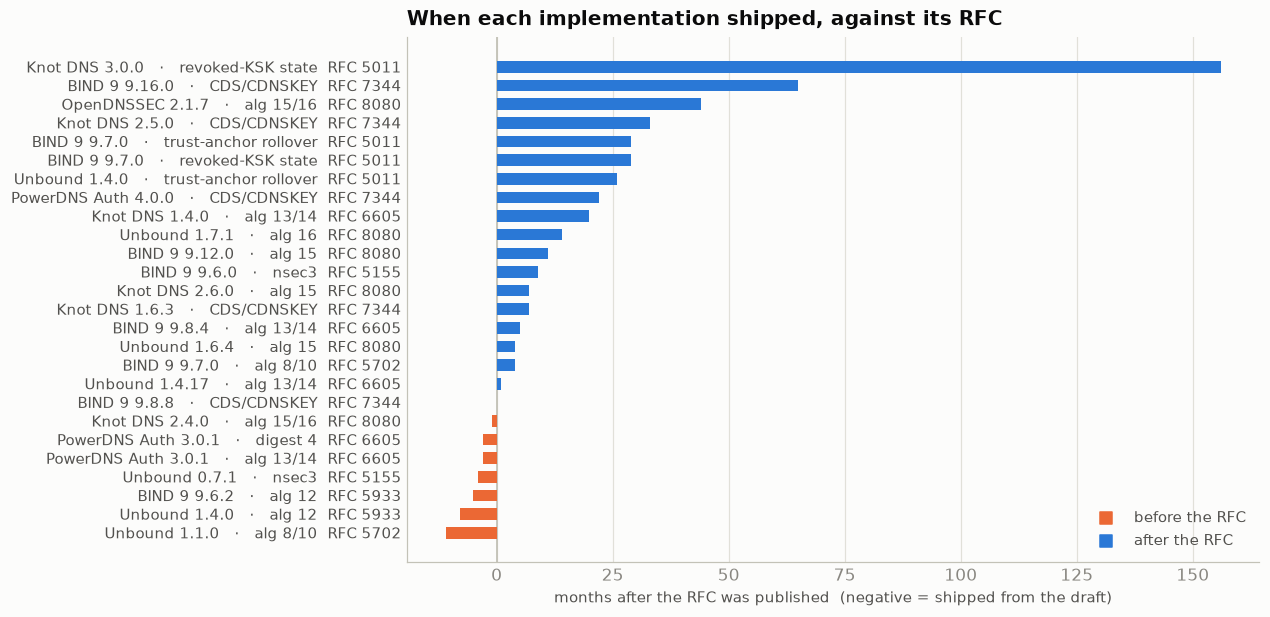

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/03_pre_rfc_lead.png')

In [5]:
pre = [r for r in SUP["support"] if r.get("standard_codepoint", True)]
lead = []
RFC_PUB = {"RFC 5011": "2007-09", "RFC 5155": "2008-03", "RFC 5702": "2009-10",
           "RFC 5933": "2010-07", "RFC 6605": "2012-04", "RFC 7344": "2014-09",
           "RFC 8080": "2017-02"}
for r in pre:
    pub = RFC_PUB.get(r["rfc"])
    if not pub:
        continue
    months = (int(r["released"][:4]) - int(pub[:4])) * 12 + (int(r["released"][5:7]) - int(pub[5:7]))
    lead.append((months, f'{NAME[r["implementation"]]} {r["first_release"]}',
                 f'{r["observable"]}  {r["rfc"]}'))
lead.sort()
fig, ax = plt.subplots(figsize=(10, 6.2))
ys = range(len(lead))
colors = [S2 if m < 0 else S1 for m, _, _ in lead]
ax.barh(list(ys), [m for m, _, _ in lead], height=0.62, color=colors, zorder=3)
ax.axvline(0, color=BASELINE, linewidth=1.2)
ax.set_yticks(list(ys))
ax.set_yticklabels([f"{s}   ·   {o}" for _, s, o in lead], fontsize=9.5, color=INK_2)
ax.set_xlabel("months after the RFC was published  (negative = shipped from the draft)",
              color=INK_2)
style(ax, axis="x")
ax.scatter([], [], marker="s", s=70, color=S2, label="before the RFC")
ax.scatter([], [], marker="s", s=70, color=S1, label="after the RFC")
ax.legend(frameon=False, loc="lower right", fontsize=10, labelcolor=INK_2)
title(ax, "When each implementation shipped, against its RFC")
save(fig, "03_pre_rfc_lead")

## 3. The software itself

### 3.1 Release cadence

1,083 stable releases across eight projects. BIND's odd minors from 9.13 on are
development branches and are excluded — counting them dates `dnssec-policy`'s CDS
publication to 9.15.6 in 2019 rather than 9.16.0 in 2020.

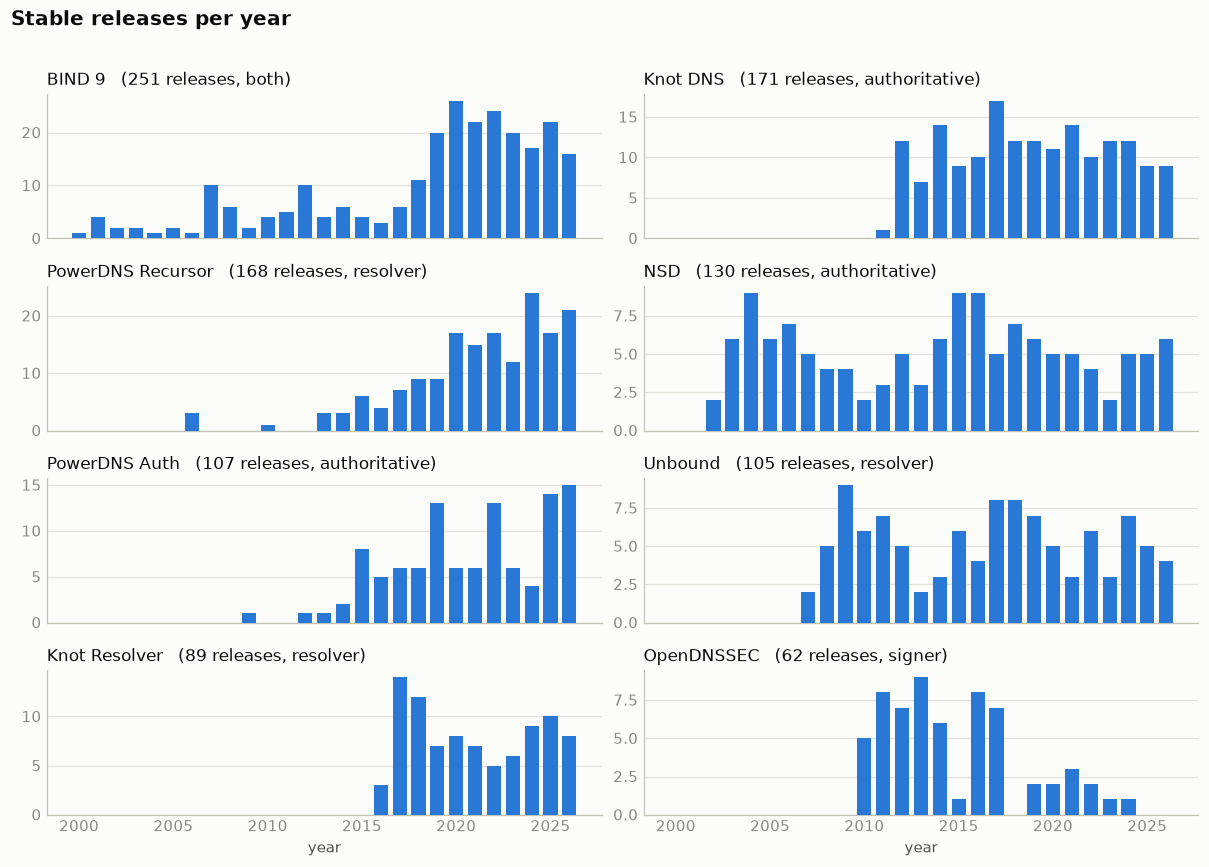

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/04_release_cadence.png')

In [6]:
order = sorted(REL, key=lambda p: -len(REL[p]["releases"]))
fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharex=True)
for ax, proj in zip(axes.ravel(), order):
    years = collections.Counter(int(d[:4]) for d in REL[proj]["releases"].values())
    span = range(min(years), max(years) + 1)
    ax.bar(list(span), [years.get(y, 0) for y in span], color=S1, width=0.75, zorder=3)
    style(ax)
    ax.set_title(f'{NAME[proj]}   ({len(REL[proj]["releases"])} releases, '
                 f'{REL[proj]["role"]})', loc="left", fontsize=11, color=INK)
    ax.tick_params(labelsize=9.5)
axes[-1][0].set_xlabel("year", color=INK_2)
axes[-1][1].set_xlabel("year", color=INK_2)
fig.suptitle("Stable releases per year", x=0.005, ha="left", fontsize=13,
             fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save(fig, "04_release_cadence")

### 3.2 Who supported what, and when

Cell colour is the year the capability first shipped in a stable release —
darker is later. Blank means the project has no row for that mechanism in the
dataset, not that it lacks support.

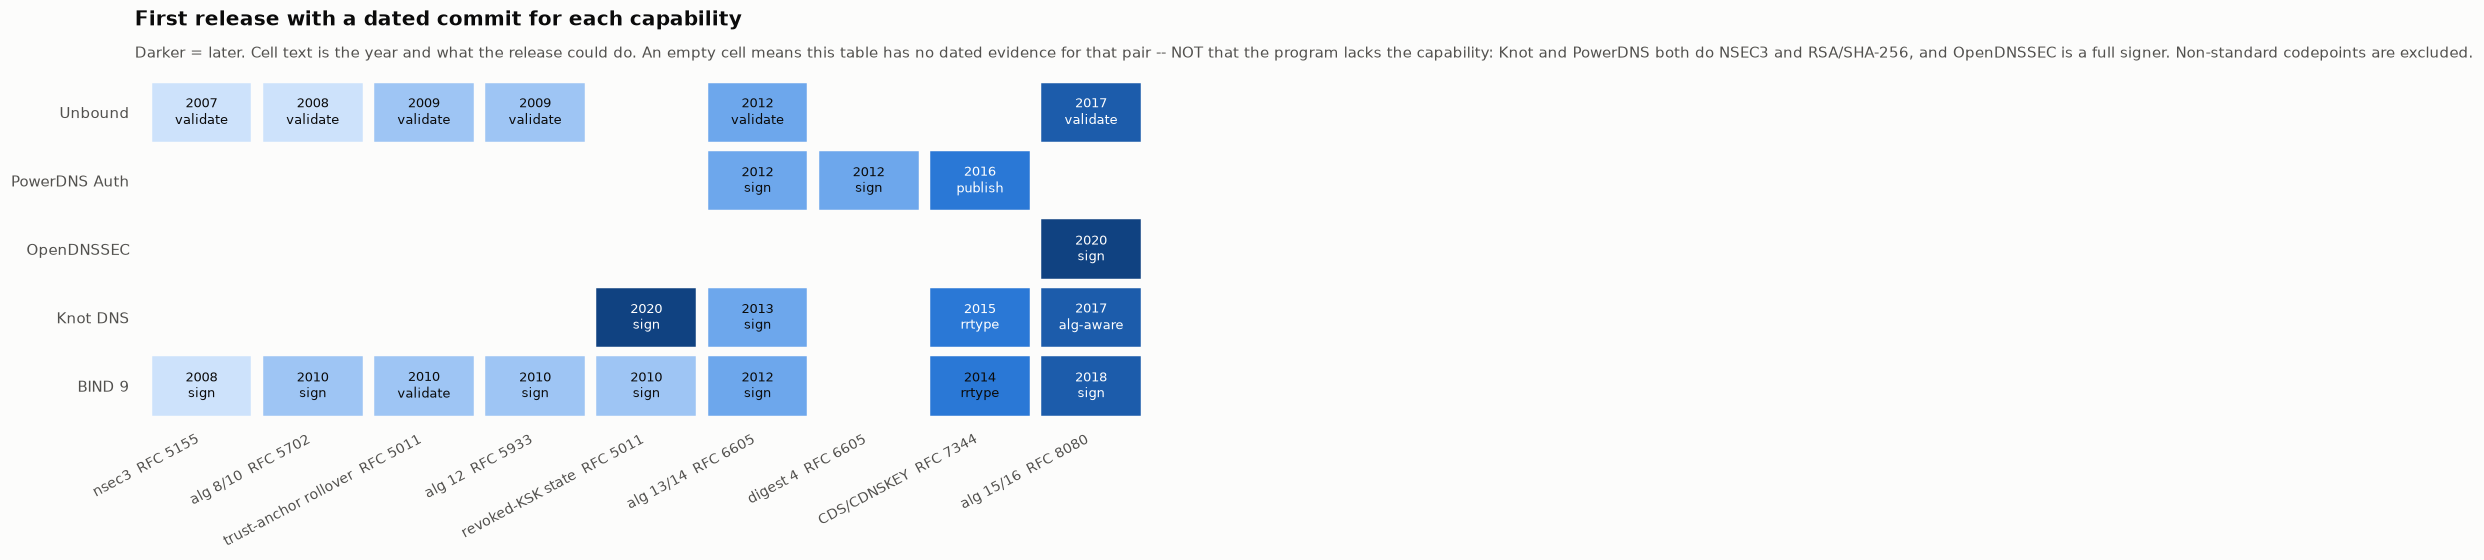

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/05_support_matrix.png')

In [7]:
alias = {"alg 15": "alg 15/16", "alg 16": "alg 15/16", "alg 13": "alg 13/14",
         "alg 14": "alg 13/14", "alg 8": "alg 8/10", "alg 10": "alg 8/10"}
grid = {}
# Non-standard codepoints are excluded here as they are everywhere else in this
# project. PowerDNS Auth 3.3.1 (2013) signed EdDSA on private codepoint 250,
# five years before RFC 8080 assigned 15/16; leaving it in put a 2013 cell in
# the RFC 8080 column and made PowerDNS look like it shipped the standard four
# years before the standard existed.
for r in SUP["support"]:
    if not r.get("standard_codepoint", True):
        continue
    obs = alias.get(r["observable"], r["observable"])
    key = (NAME[r["implementation"]], f'{obs}\n{r["rfc"]}')
    yr = int(r["released"][:4])
    if key not in grid or yr < grid[key][0]:
        grid[key] = (yr, r["capability"])

projects = sorted({k[0] for k in grid})
mechs = sorted({k[1] for k in grid}, key=lambda m: min(v[0] for k, v in grid.items()
                                                       if k[1] == m))
lo = min(v[0] for v in grid.values()); hi = max(v[0] for v in grid.values())
SHORT_CAP = {"algorithm-aware": "alg-aware", "revoked-KSK state": "revoked-KSK"}
fig, ax = plt.subplots(figsize=(12, 4.2))
for xi, m in enumerate(mechs):
    for yi, p in enumerate(projects):
        cell = grid.get((p, m))
        if not cell:
            continue
        frac = (cell[0] - lo) / max(hi - lo, 1)
        colour = RAMP[min(int(frac * (len(RAMP) - 1) + 0.5), len(RAMP) - 1)]
        ax.add_patch(plt.Rectangle((xi - 0.44, yi - 0.42), 0.88, 0.84, color=colour,
                                   zorder=3))
        ax.text(xi, yi, f"{cell[0]}\n{SHORT_CAP.get(cell[1], cell[1])}", ha="center",
                va="center", fontsize=8.5,
                color="#ffffff" if frac > 0.55 else INK, zorder=4)
ax.set_xlim(-0.6, len(mechs) - 0.4); ax.set_ylim(-0.6, len(projects) - 0.4)
ax.set_xticks(range(len(mechs)))
ax.set_xticklabels([m.replace("\n", "  ") for m in mechs], fontsize=9,
                   color=INK_2, rotation=28, ha="right")
ax.set_yticks(range(len(projects))); ax.set_yticklabels(projects, fontsize=10, color=INK_2)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)
title(ax, "First release with a dated commit for each capability",
      "Darker = later. Cell text is the year and what the release could do. An empty cell means this table has no "
      "dated evidence for that pair -- NOT that the program lacks the capability: Knot and PowerDNS both do NSEC3 "
      "and RSA/SHA-256, and OpenDNSSEC is a full signer. Non-standard codepoints are excluded.")
save(fig, "05_support_matrix")

### 3.3 Default changes — the only mechanism that reaches an operator who decided nothing

Six of the seven propagate silently on upgrade. BIND's `dnssec-policy` is opt-in:
an operator has to write `dnssec-policy default;` to get it.

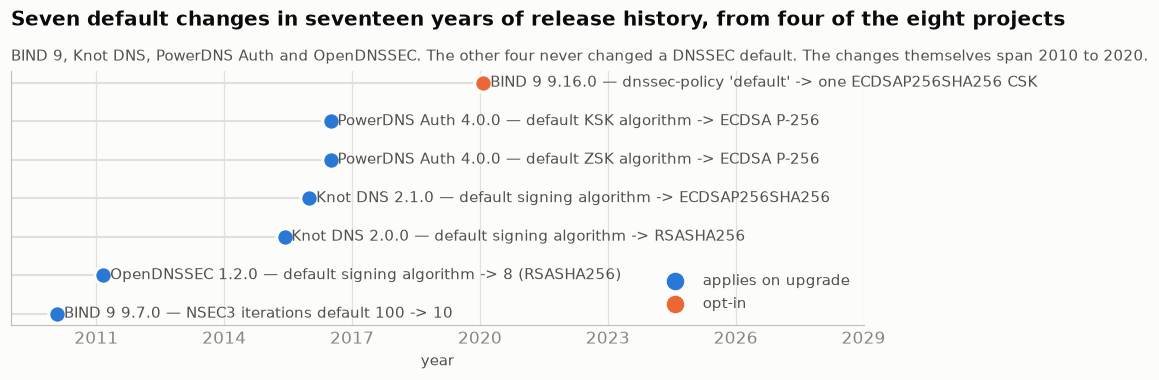

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/06_default_changes.png')

In [8]:
SHORT_WHAT = {"built-in dnssec-policy 'default' signs with one ECDSAP256SHA256 CSK":
              "dnssec-policy 'default' -> one ECDSAP256SHA256 CSK"}
dc = sorted(SUP["default_changes"], key=lambda r: r["released"])
fig, ax = plt.subplots(figsize=(10, 3.0))
for i, r in enumerate(dc):
    x = to_year(r["released"])
    opt = r.get("opt_in", False)
    ax.scatter(x, i, s=130, color=S2 if opt else S1, zorder=3, edgecolor=SURFACE,
               linewidth=2)
    ax.text(x + 0.16, i,
            f'{NAME[r["implementation"]]} {r["first_release"]} — '
            f'{SHORT_WHAT.get(r["what"], r["what"])}',
            va="center", fontsize=9.5, color=INK_2)
    ax.plot([to_year("2009-01"), x], [i, i], color=GRID, linewidth=1.4, zorder=1)
ax.set_yticks([]); ax.set_xlim(2009, 2029)
ax.set_xlabel("year", color=INK_2)
year_axis(ax)
style(ax, axis="x")
ax.scatter([], [], s=110, color=S1, label="applies on upgrade")
ax.scatter([], [], s=110, color=S2, label="opt-in")
ax.legend(frameon=False, loc="lower right", fontsize=10, labelcolor=INK_2)
title(ax, "Seven default changes in seventeen years of release history, from four of the eight projects",
      "BIND 9, Knot DNS, PowerDNS Auth and OpenDNSSEC. The other four never changed a DNSSEC default. "
      "The changes themselves span 2010 to 2020.")
save(fig, "06_default_changes")

## 4. Adoption, and whether releases explain it

### 4.1 The curves

Reverse rates use the strict **AFRINIC + ARIN** panel, the same population as
`out/analysis/adoption_measures.json`; summing all five RIRs double-counts names
present in more than one and moves every crossing date. Forward rates pool the
seven forward TLDs, which are disjoint zones, so that pooling is exact.

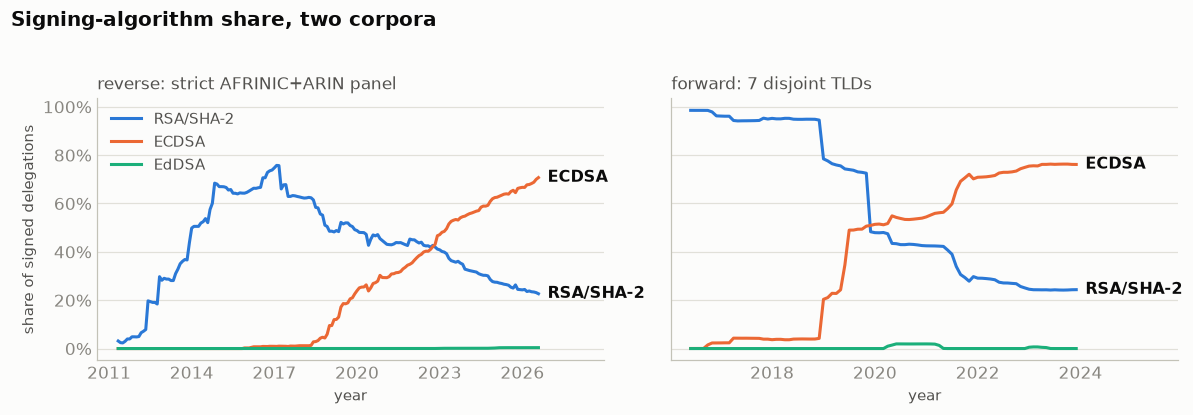

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/07_adoption_curves.png')

In [9]:
CURVES = [("alg 8/10", ["8", "10"], "RSA/SHA-2", S1),
          ("alg 13/14", ["13", "14"], "ECDSA", S2),
          ("alg 15/16", ["15", "16"], "EdDSA", S3)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (basis, df, dim, src, label) in zip(
        axes, [("reverse", PAN, "algorithm_ds", PANEL_SOURCE,
                "reverse: strict AFRINIC+ARIN panel"),
               ("zonefile", SRV, "algorithm_dnskey", None,
                "forward: 7 disjoint TLDs")]):
    for _, vals, name, colour in CURVES:
        s = share(df, basis, dim, vals, source=src)
        xs = [to_year(m) for m in s.index]
        ax.plot(xs, s.values, color=colour, linewidth=2, label=name, zorder=3)
        if s.max() > 3:
            ax.annotate(name, (xs[-1], s.values[-1]), xytext=(6, 0),
                        textcoords="offset points", color=INK, fontsize=10.5,
                        fontweight="bold", va="center")
    style(ax); pct(ax)
    ax.set_title(label, loc="left", fontsize=11, color=INK_2)
    ax.set_xlabel("year", color=INK_2)
    year_axis(ax)
    ax.set_xlim(right=ax.get_xlim()[1] + 1.6)
axes[0].set_ylabel("share of signed delegations", color=INK_2)
axes[0].legend(frameon=False, loc="upper left", fontsize=10, labelcolor=INK_2)
fig.suptitle("Signing-algorithm share, two corpora", x=0.005, ha="left", fontsize=13,
             fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.95])
save(fig, "07_adoption_curves")

### 4.2 Which date predicts takeoff?

Time from each candidate date to the month the value first crossed 1%. Where a
default change exists it is three to six times closer than the RFC.

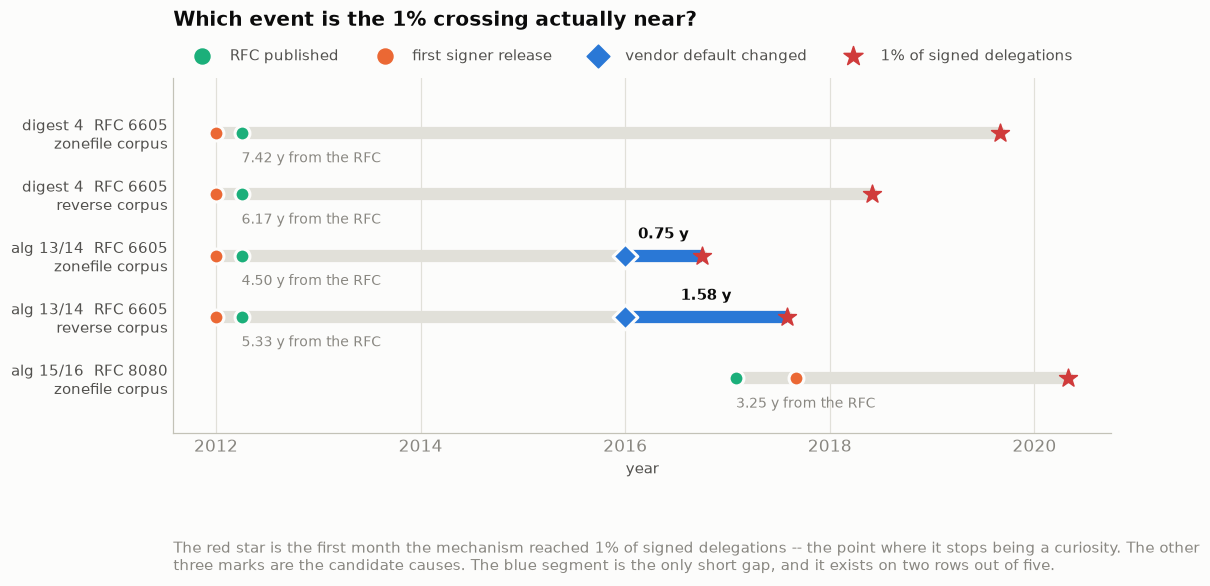

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/08_takeoff_lags.png')

In [10]:
rows = [r for r in RA["takeoff"] if r["first_month_over_1pct"] and not r["censored_start"]]
rows.sort(key=lambda r: to_year(r["rfc_published"]), reverse=True)

fig, ax = plt.subplots(figsize=(11, 4.2))
for i, r in enumerate(rows):
    x_rfc = to_year(r["rfc_published"])
    x_sig = to_year(r["first_signer_released"])
    x_1pct = to_year(r["first_month_over_1pct"])
    x_def = to_year(r["default_released"]) if r["default_released"] else None

    ax.plot([min(x_rfc, x_sig), x_1pct], [i, i], color=GRID, linewidth=8,
            solid_capstyle="round", zorder=1)
    ax.scatter(x_rfc, i, s=95, color=S3, zorder=4, edgecolor=SURFACE, linewidth=2)
    ax.scatter(x_sig, i, s=95, color=S2, zorder=4, edgecolor=SURFACE, linewidth=2)
    if x_def is not None:
        ax.plot([x_def, x_1pct], [i, i], color=S1, linewidth=8, solid_capstyle="butt",
                zorder=2)
        ax.scatter(x_def, i, s=130, color=S1, marker="D", zorder=5,
                   edgecolor=SURFACE, linewidth=2)
        ax.text((x_def + x_1pct) / 2, i + 0.28,
                f'{r["from_default_change_to_1pct_years"]:.2f} y', ha="center",
                fontsize=9.5, color=INK, fontweight="bold")
    ax.scatter(x_1pct, i, s=150, color=CRITICAL, marker="*", zorder=5)
    ax.text(x_rfc, i - 0.30, f'{r["from_rfc_to_1pct_years"]:.2f} y from the RFC',
            fontsize=9, color=MUTED, ha="left", va="top")

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f'{r["observable"]}  {r["rfc"]}\n{r["basis"]} corpus' for r in rows],
                   fontsize=10, color=INK_2)
ax.set_ylim(-0.9, len(rows) - 0.1)
ax.set_xlabel("year", color=INK_2)
year_axis(ax)
style(ax, axis="x")
for lbl, colour, mk, sz in (("RFC published", S3, "o", 95),
                            ("first signer release", S2, "o", 95),
                            ("vendor default changed", S1, "D", 110),
                            ("1% of signed delegations", CRITICAL, "*", 170)):
    ax.scatter([], [], s=sz, color=colour, marker=mk, label=lbl)
ax.legend(frameon=False, fontsize=10, labelcolor=INK_2, ncol=4, loc="lower left",
          bbox_to_anchor=(0, 1.0))
ax.set_title("Which event is the 1% crossing actually near?", loc="left", color=INK,
             fontweight="bold", pad=34)
metric(ax, "The red star is the first month the mechanism reached 1% of signed "
           "delegations -- the point where it stops being a curiosity. The other three "
           "marks are the candidate causes. The blue segment is the only short gap, and "
           "it exists on two rows out of five.")
save(fig, "08_takeoff_lags")

### 4.3 The event studies do not confirm it

Mean monthly change in share, twelve months either side of each release. Events
firing above 20% share are excluded from interpretation: a bounded series must
decelerate as it approaches its ceiling, so a late event inherits a negative
delta it did not cause.

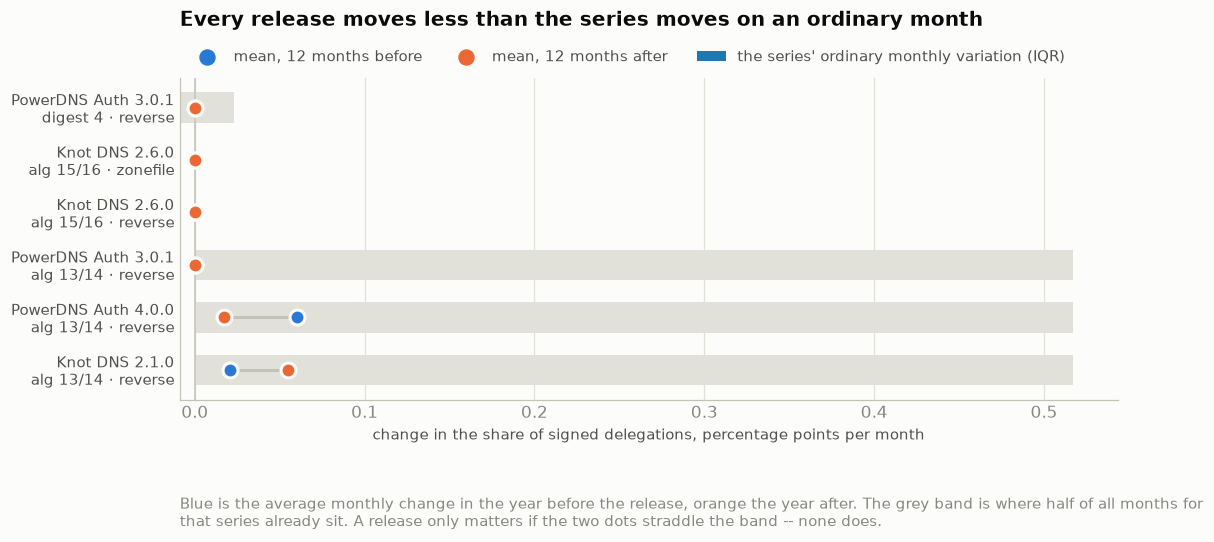

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/09_event_studies.png')

In [11]:
ev = [e for e in RA["event_studies"] if not e["late_curve"]]
ev.sort(key=lambda e: (e["kind"], e["observable"]))

# The effect size means nothing without the series' own month-to-month variation
# beside it. VALS maps an observable back to its codepoints so the noise band can
# be recomputed here rather than asserted.
VALS = {"alg 8/10": ["8", "10"], "alg 12": ["12"], "alg 13/14": ["13", "14"],
        "alg 15/16": ["15", "16"], "digest 4": ["4"]}


def noise_band(observable, basis):
    '''Interquartile range of this series' ordinary monthly change.'''
    dim = ("digest_type_ds" if observable == "digest 4" else
           ("algorithm_ds" if basis == "reverse" else "algorithm_dnskey"))
    df, src = ((PAN, PANEL_SOURCE) if basis == "reverse" else (SRV, None))
    d = share(df, basis, dim, VALS[observable], source=src).diff().dropna()
    return float(d.quantile(0.25)), float(d.quantile(0.75))


def pretty(sw):
    key, _, ver = sw.partition(" ")
    return f"{NAME.get(key, key)} {ver}"


labels = [f'{pretty(e["software"])}\n{e["observable"]} · {e["basis"]}' for e in ev]
fig, ax = plt.subplots(figsize=(11, 3.8))
for i, e in enumerate(ev):
    q1, q3 = noise_band(e["observable"], e["basis"])
    ax.barh(i, q3 - q1, left=q1, height=0.58, color=GRID, zorder=1)
    ax.plot([e["mean_pp_before"], e["mean_pp_after"]], [i, i], color=BASELINE,
            linewidth=2, zorder=2)
    ax.scatter(e["mean_pp_before"], i, s=95, color=S1, zorder=4, edgecolor=SURFACE,
               linewidth=2)
    ax.scatter(e["mean_pp_after"], i, s=95, color=S2, zorder=4, edgecolor=SURFACE,
               linewidth=2)

ax.set_yticks(range(len(ev))); ax.set_yticklabels(labels, fontsize=9.5, color=INK_2)
ax.axvline(0, color=BASELINE, linewidth=1)
ax.set_xlabel("change in the share of signed delegations, percentage points per month",
              color=INK_2)
style(ax, axis="x")
ax.barh([], [], color=GRID, edgecolor=GRID,
        label="the series' ordinary monthly variation (IQR)")
ax.scatter([], [], s=95, color=S1, label="mean, 12 months before")
ax.scatter([], [], s=95, color=S2, label="mean, 12 months after")
ax.legend(frameon=False, fontsize=9.5, labelcolor=INK_2, ncol=3, loc="lower left",
          bbox_to_anchor=(0, 1.0))
ax.set_title("Every release moves less than the series moves on an ordinary month",
             loc="left", color=INK, fontweight="bold", pad=34)
metric(ax, "Blue is the average monthly change in the year before the release, orange "
           "the year after. The grey band is where half of all months for that series "
           "already sit. A release only matters if the two dots straddle the band -- "
           "none does.")
save(fig, "09_event_studies")

## 5. NSEC3: the one place a validator can force a zone to change

### 5.1 The iteration collapse

Resolver vendors converged on a 150-iteration cap in 2021, stated outright in
Unbound's commit message. Zones moved two months later — and ten months before
RFC 9276 documented it.

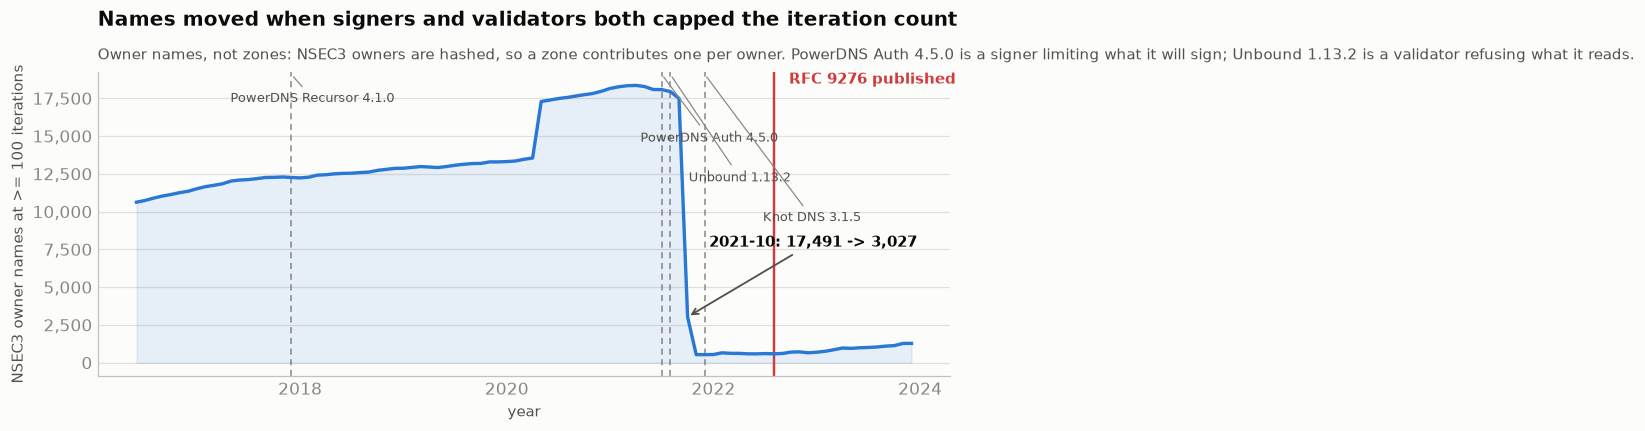

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/10_nsec3_collapse.png')

In [12]:
col = A["nsec3_iteration_collapse"]
h = col["high_iteration_names_by_month"]
months = sorted(h)
xs = [to_year(m) for m in months]
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(xs, [h[m] for m in months], color=S1, linewidth=2.2, zorder=3)
ax.fill_between(xs, [h[m] for m in months], color=S1, alpha=0.10, zorder=2)
# Three of the four limits land within seven months of each other in 2021, so
# their labels are staggered; stacked at one height they overprint.
top = ax.get_ylim()[1]
for k, lim in enumerate(sorted(col["validator_limits"], key=lambda r: r["released"])):
    x = to_year(lim["released"][:7])
    if not (xs[0] <= x <= xs[-1]):
        continue
    ax.axvline(x, color=MUTED, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
    ax.annotate(f'{NAME[lim["implementation"]]} {lim["first_release"]}',
                xy=(x, top * 0.99), xytext=(-40 + 26 * k, -18 - 26 * k),
                textcoords="offset points", fontsize=8.5, color=INK_2, ha="left",
                arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8))
x9276 = to_year("2022-08")
ax.axvline(x9276, color=CRITICAL, linewidth=1.6, zorder=1)
ax.annotate("RFC 9276 published", xy=(x9276, top * 0.99), xytext=(10, -6),
            textcoords="offset points", fontsize=9.5, color=CRITICAL,
            fontweight="bold", ha="left")
worst = col["largest_single_month_fall"]
ax.annotate(f'{worst["month"]}: {worst["before"]:,} -> {worst["after"]:,}',
            (to_year(worst["month"]), worst["after"]), xytext=(14, 46),
            textcoords="offset points", fontsize=10, color=INK, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=INK_2, linewidth=1.2))
style(ax)
ax.set_ylabel("NSEC3 owner names at >= 100 iterations", color=INK_2)
ax.set_xlabel("year", color=INK_2)
year_axis(ax)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
title(ax, "Names moved when signers and validators both capped the iteration count",
      "Owner names, not zones: NSEC3 owners are hashed, so a zone contributes one per owner. "
      "PowerDNS Auth 4.5.0 is a signer limiting what it will sign; Unbound 1.13.2 is a validator refusing what it reads.")
save(fig, "10_nsec3_collapse")

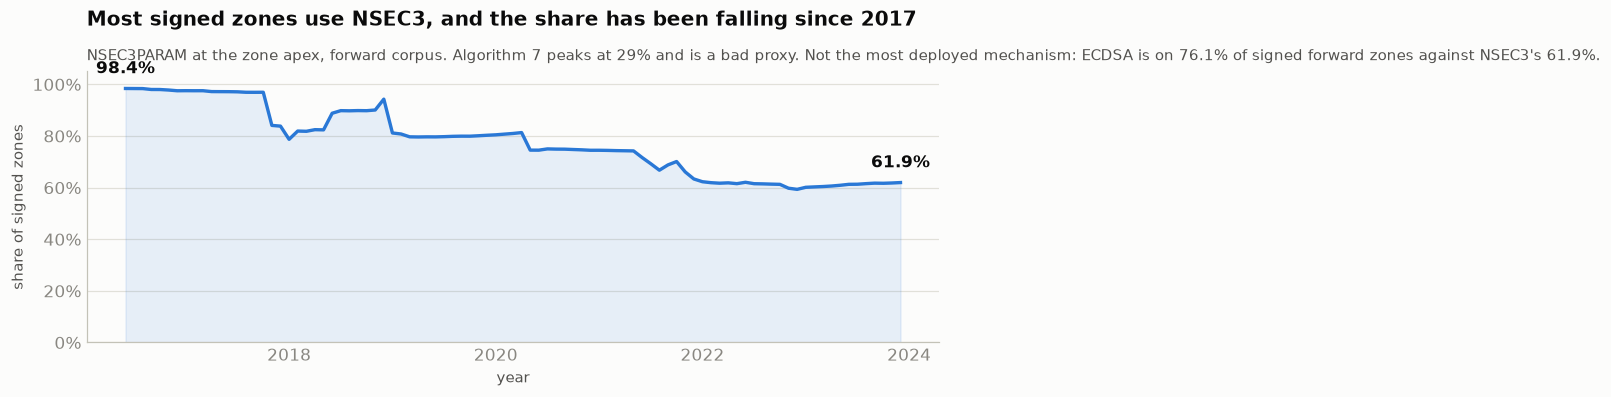

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/11_nsec3_prevalence.png')

In [13]:
f = SRV[SRV.basis == "zonefile"]
par = f[(f.dimension == "rr_type") & (f.value.astype(str) == "NSEC3PARAM")] \
    .groupby("month").domains_peak.sum()
signed = f[(f.dimension == "algorithm_dnskey") & (f.value.astype(str) == "_total")] \
    .groupby("month").domains_peak.sum()
s = (par / signed * 100).dropna().sort_index()
xs = [to_year(m) for m in s.index]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(xs, s.values, color=S1, linewidth=2.2, zorder=3)
ax.fill_between(xs, s.values, color=S1, alpha=0.10, zorder=2)
for m in (s.index[0], s.index[-1]):
    ax.annotate(f"{s[m]:.1f}%", (to_year(m), s[m]), xytext=(0, 10),
                textcoords="offset points", ha="center", fontsize=11, color=INK,
                fontweight="bold")
style(ax); pct(ax)
ax.set_ylim(0, 105)
ax.set_ylabel("share of signed zones", color=INK_2)
ax.set_xlabel("year", color=INK_2)
year_axis(ax)
title(ax, "Most signed zones use NSEC3, and the share has been falling since 2017",
      "NSEC3PARAM at the zone apex, forward corpus. Algorithm 7 peaks at 29% and is a bad proxy. "
      "Not the most deployed mechanism: ECDSA is on 76.1% of signed forward zones against NSEC3's 61.9%.")
save(fig, "11_nsec3_prevalence")

## 6. The unit of change is the operator, not the zone

`.se` and `.nu` are both run by the Swedish Internet Foundation; `.ch` and `.li`
by SWITCH. In 20 of 21 detected jumps the partner zone moves in the same month.

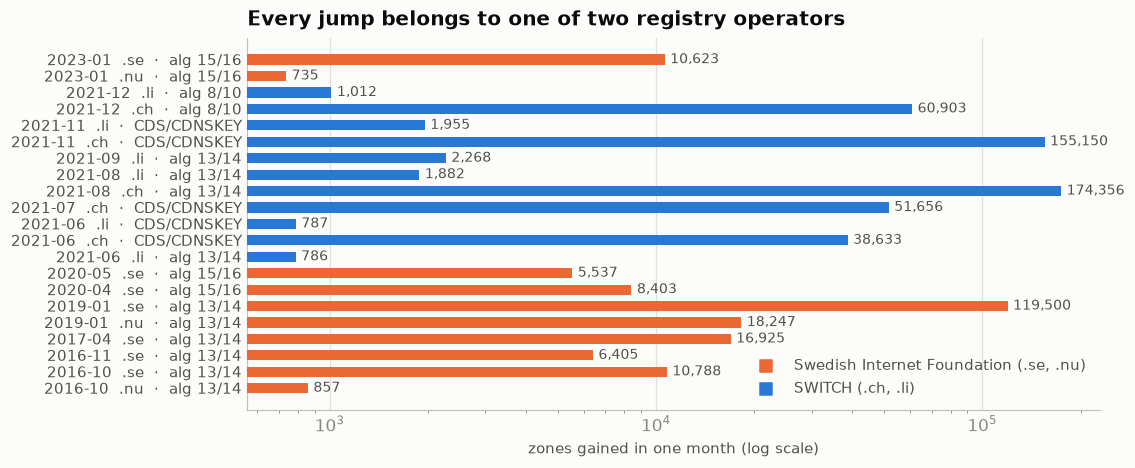

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/12_portfolio_jumps.png')

In [14]:
PARTNER = {"se": "nu", "nu": "se", "ch": "li", "li": "ch"}
OPNAME = {"se": "Swedish Internet Foundation", "nu": "Swedish Internet Foundation",
          "ch": "SWITCH", "li": "SWITCH"}
jumps = [(obs, j) for obs, js in A["portfolio_jumps"].items() for j in js]
jumps.sort(key=lambda t: t[1]["month"])
fig, ax = plt.subplots(figsize=(10, 4.4))
for i, (obs, j) in enumerate(jumps):
    ax.barh(i, j["delta_zones"], height=0.62,
            color=S1 if OPNAME.get(j["source"]) == "SWITCH" else S2, zorder=3)
    ax.text(j["delta_zones"] * 1.04, i, f'{j["delta_zones"]:,}', va="center",
            fontsize=9, color=INK_2)
ax.set_yticks(range(len(jumps)))
ax.set_yticklabels([f'{j["month"]}  .{j["source"]}  ·  {obs}' for obs, j in jumps],
                   fontsize=9.5, color=INK_2)
ax.set_xscale("log")
ax.set_xlabel("zones gained in one month (log scale)", color=INK_2)
style(ax, axis="x")
ax.scatter([], [], marker="s", s=70, color=S2, label="Swedish Internet Foundation (.se, .nu)")
ax.scatter([], [], marker="s", s=70, color=S1, label="SWITCH (.ch, .li)")
ax.legend(frameon=False, loc="lower right", fontsize=10, labelcolor=INK_2)
title(ax, "Every jump belongs to one of two registry operators")
save(fig, "12_portfolio_jumps")

## 7. The CVE record

441 CVEs touching the eight implementations or naming DNS/DNSSEC itself, from
NVD per-product CPE queries, NVD keyword queries and the projects' own git
history. None of the three sources subsumes the others.

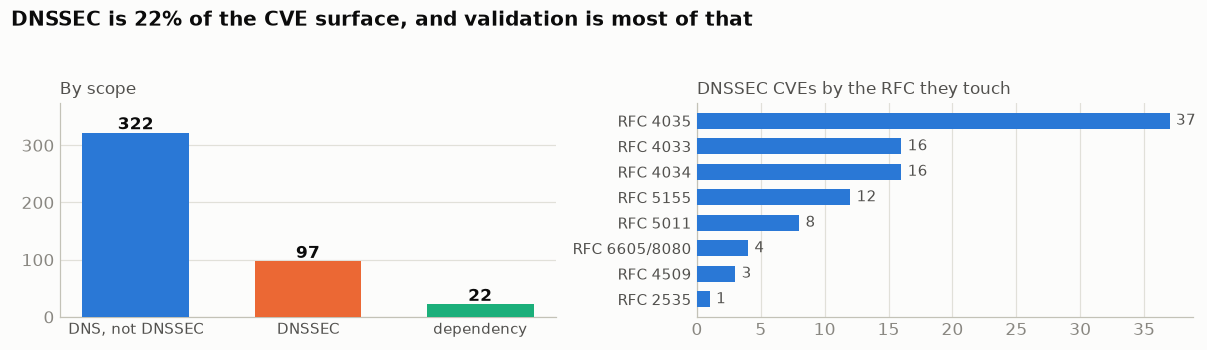

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/13_cve_scope_and_rfc.png')

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
scope = CV["totals"]["by_scope"]
order = ["dns", "dnssec", "dependency"]
lab = {"dns": "DNS, not DNSSEC", "dnssec": "DNSSEC", "dependency": "dependency"}
ax = axes[0]
ax.bar(range(len(order)), [scope[k] for k in order], color=[S1, S2, S3], width=0.62,
       zorder=3)
for i, k in enumerate(order):
    ax.text(i, scope[k] + 6, f"{scope[k]}", ha="center", fontsize=11, color=INK,
            fontweight="bold")
ax.set_xticks(range(len(order))); ax.set_xticklabels([lab[k] for k in order], fontsize=10,
                                                     color=INK_2)
style(ax); ax.set_ylim(0, max(scope.values()) * 1.16)
ax.set_title("By scope", loc="left", fontsize=11, color=INK_2)

ax = axes[1]
mech = CV["totals"]["by_mechanism"]
RFC_OF = {"nsec3": "RFC 5155", "nsec": "RFC 4034", "dnskey": "RFC 4034",
          "rrsig": "RFC 4035", "validation": "RFC 4035", "trust-anchor": "RFC 5011",
          "algorithm": "RFC 6605/8080", "ds-digest": "RFC 4509",
          "dnssec-other": "RFC 4033", "nxt-sig-key": "RFC 2535"}
byrfc = collections.Counter()
for k, v in mech.items():
    byrfc[RFC_OF.get(k, k)] += v
items = byrfc.most_common()
ax.barh(range(len(items)), [v for _, v in items], height=0.62, color=S1, zorder=3)
for i, (_, v) in enumerate(items):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=10, color=INK_2)
ax.set_yticks(range(len(items)))
ax.set_yticklabels([k for k, _ in items], fontsize=10, color=INK_2)
ax.invert_yaxis(); style(ax, axis="x")
ax.set_title("DNSSEC CVEs by the RFC they touch", loc="left", fontsize=11, color=INK_2)
fig.suptitle("DNSSEC is 22% of the CVE surface, and validation is most of that",
             x=0.005, ha="left", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, "13_cve_scope_and_rfc")

### 7.1 The whole DNSSEC CVE surface is on the validating side

NSD serves zones somebody else signed and OpenDNSSEC signs them; neither
validates, and neither has a DNSSEC CVE. This is exactly the half of DNSSEC this
project's zone-file measurement cannot see.

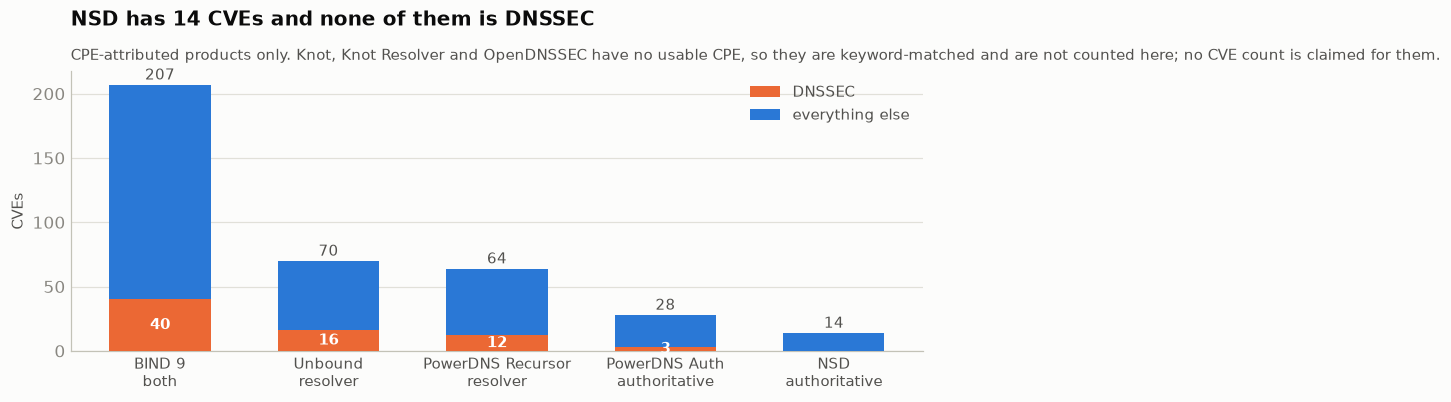

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/14_cve_by_project.png')

In [16]:
qm = CV["query_method"]
cpe = [p for p in CV["per_project"] if qm[p] == "cpe"]
cpe.sort(key=lambda p: -sum(CV["per_project"][p].values()))
dn = [CV["per_project"][p].get("dnssec", 0) for p in cpe]
other = [sum(CV["per_project"][p].values()) - d for p, d in zip(cpe, dn)]
x = range(len(cpe))
fig, ax = plt.subplots(figsize=(10, 3.3))
ax.bar(x, dn, color=S2, width=0.6, label="DNSSEC", zorder=3)
ax.bar(x, other, bottom=dn, color=S1, width=0.6, label="everything else", zorder=3)
for i, (d, o) in enumerate(zip(dn, other)):
    if d:
        ax.text(i, d / 2, str(d), ha="center", va="center", fontsize=10, color="#ffffff",
                fontweight="bold")
    ax.text(i, d + o + 4, str(d + o), ha="center", fontsize=10, color=INK_2)
ax.set_xticks(list(x))
ax.set_xticklabels([f'{NAME[p]}\n{CV["project_roles"][p]}' for p in cpe], fontsize=9.5,
                   color=INK_2)
style(ax)
ax.set_ylabel("CVEs", color=INK_2)
ax.legend(frameon=False, loc="upper right", fontsize=10, labelcolor=INK_2)
title(ax, "NSD has 14 CVEs and none of them is DNSSEC",
      "CPE-attributed products only. Knot, Knot Resolver and OpenDNSSEC have no usable CPE, so they are "
      "keyword-matched and are not counted here; no CVE count is claimed for them.")
save(fig, "14_cve_by_project")

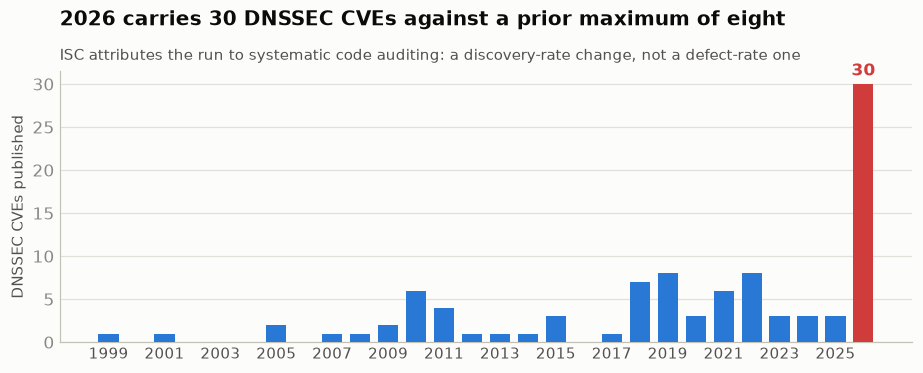

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/15_cve_per_year.png')

In [17]:
years = collections.Counter(c["published"][:4] for c in CV["cves"]
                            if c["scope"] == "dnssec" and c["published"])
span = [str(y) for y in range(min(int(y) for y in years), max(int(y) for y in years) + 1)]
vals = [years.get(y, 0) for y in span]
fig, ax = plt.subplots(figsize=(10, 3.2))
colours = [CRITICAL if y == "2026" else S1 for y in span]
ax.bar(range(len(span)), vals, color=colours, width=0.72, zorder=3)
ax.text(len(span) - 1, vals[-1] + 1, f"{vals[-1]}", ha="center", fontsize=11,
        color=CRITICAL, fontweight="bold")
ax.set_xticks(range(0, len(span), 2))
ax.set_xticklabels(span[::2], fontsize=9.5, color=INK_2)
style(ax); ax.set_ylabel("DNSSEC CVEs published", color=INK_2)
title(ax, "2026 carries 30 DNSSEC CVEs against a prior maximum of eight",
      "ISC attributes the run to systematic code auditing: a discovery-rate change, not a defect-rate one")
save(fig, "15_cve_per_year")

### 7.2 Fixes, embargoes, and how long the ecosystem stays exposed

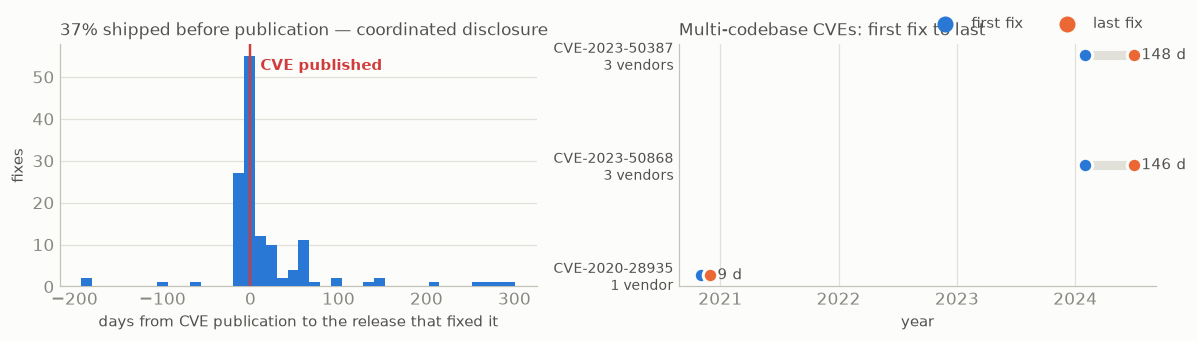

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/16_cve_latency_and_spread.png')

In [18]:
lat = []
for c in CV["cves"]:
    for p, f in c["fixes"].items():
        if c["published"] and f.get("released"):
            lat.append((pd.Timestamp(f["released"]) - pd.Timestamp(c["published"])).days)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
ax = axes[0]
ax.hist([d for d in lat if -200 <= d <= 400], bins=40, color=S1, zorder=3)
ax.axvline(0, color=CRITICAL, linewidth=1.6, zorder=4)
ax.text(0, ax.get_ylim()[1] * 0.94, "  CVE published", color=CRITICAL, fontsize=9.5,
        fontweight="bold", va="top")
style(ax)
ax.set_xlabel("days from CVE publication to the release that fixed it", color=INK_2)
ax.set_ylabel("fixes", color=INK_2)
share_before = sum(1 for d in lat if d < 0) / len(lat) * 100
ax.set_title(f"{share_before:.0f}% shipped before publication — coordinated disclosure",
             loc="left", fontsize=11, color=INK_2)

ax = axes[1]
co = [c for c in CV["coordinated"] if c["spread_days"] is not None]
co.sort(key=lambda c: c["spread_days"])
for i, c in enumerate(co):
    a, b = to_year(c["first_release"][:7]), to_year(c["last_release"][:7])
    ax.plot([a, b], [i, i], color=GRID, linewidth=6, solid_capstyle="round", zorder=1)
    ax.scatter(a, i, s=90, color=S1, zorder=3, edgecolor=SURFACE, linewidth=2)
    ax.scatter(b, i, s=90, color=S2, zorder=3, edgecolor=SURFACE, linewidth=2)
    ax.text(b + 0.06, i, f'{c["spread_days"]} d', va="center", fontsize=9.5, color=INK_2)
ax.set_yticks(range(len(co)))
ax.set_yticklabels([f'{c["cve"]}\n{len(c["vendors"])} vendor'
                    f'{"" if len(c["vendors"]) == 1 else "s"}' for c in co],
                   fontsize=9, color=INK_2)
ax.set_xlabel("year", color=INK_2)
year_axis(ax)
style(ax, axis="x")
ax.scatter([], [], s=90, color=S1, label="first fix")
ax.scatter([], [], s=90, color=S2, label="last fix")
# Above the axes: inside it, the legend lands on the 2020 row.
ax.legend(frameon=False, fontsize=9.5, labelcolor=INK_2, ncol=2,
          loc="lower right", bbox_to_anchor=(1.0, 1.0))
ax.set_title("Multi-codebase CVEs: first fix to last", loc="left", fontsize=11,
             color=INK_2)
fig.tight_layout()
save(fig, "16_cve_latency_and_spread")

### 7.3 Vulnerability does not follow deployment

Only 16 of 97 DNSSEC CVEs name a specific mechanism; 69 sit in RFC 4033/4034/4035,
whose exposure is 100% of signed zones by construction. Among the mechanisms that
can be matched, peak share explains nothing.

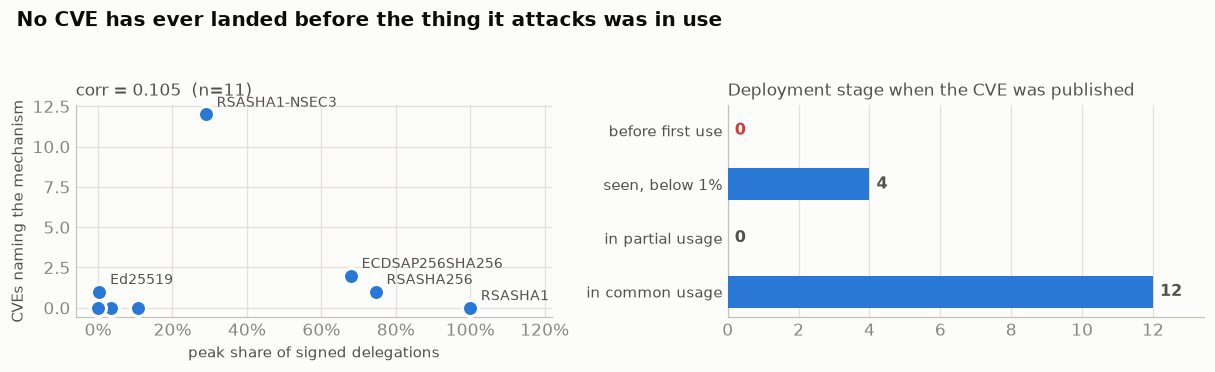

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/17_cve_vs_adoption.png')

In [19]:
rows = [r for r in CA["changes"] if r["matchable"] and r["peak_share_pct"] is not None]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
ax.scatter([r["peak_share_pct"] for r in rows], [r["n_cves"] for r in rows], s=110,
           color=S1, zorder=3, edgecolor=SURFACE, linewidth=2)
for r in rows:
    if r["n_cves"] or r["peak_share_pct"] > 60:
        ax.annotate(r["change"], (r["peak_share_pct"], r["n_cves"]), xytext=(7, 5),
                    textcoords="offset points", fontsize=9, color=INK_2)
style(ax, axis="both"); pct(ax, axis="x")
ax.set_xlim(-6, 122)          # room for the RSASHA1 label at 100%
ax.set_xlabel("peak share of signed delegations", color=INK_2)
ax.set_ylabel("CVEs naming the mechanism", color=INK_2)
ax.set_title(f'corr = {CA["correlation_peak_share_vs_cve_count"]}  (n=11)', loc="left",
             fontsize=11, color=INK_2)

ax = axes[1]
stages = collections.Counter(c["stage_when_published"] for r in CA["changes"]
                             for c in r["cves"])
# Every stage is drawn, including the empty ones: "before first use" reading
# zero is the finding, and a category that is simply absent does not show it.
order = ["before first use", "seen, below 1%", "in partial usage", "in common usage"]
vals = [stages.get(o, 0) for o in order]
ax.barh(range(len(order)), vals, height=0.6, color=S1, zorder=3)
for i, v in enumerate(vals):
    ax.text(v + 0.2, i, str(v), va="center", fontsize=10.5,
            color=CRITICAL if v == 0 and i == 0 else INK_2, fontweight="bold")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=10, color=INK_2)
ax.set_xlim(0, max(vals) * 1.12)
ax.invert_yaxis(); style(ax, axis="x")
ax.set_title("Deployment stage when the CVE was published", loc="left", fontsize=11,
             color=INK_2)
fig.suptitle("No CVE has ever landed before the thing it attacks was in use",
             x=0.005, ha="left", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, "17_cve_vs_adoption")

## 9. Per delegation: who actually made each change

The monthly series counts delegations; it cannot say *which*. The raw reverse
corpus can, so following `query_name` month to month gives every individual
change with a date — 25,930 events over 13,654 delegations, 2009-2026.

**Reverse only.** The OpenINTEL forward per-day records are not in this
repository, so `.se`, `.nu` and `.ch` stay at TLD level here.

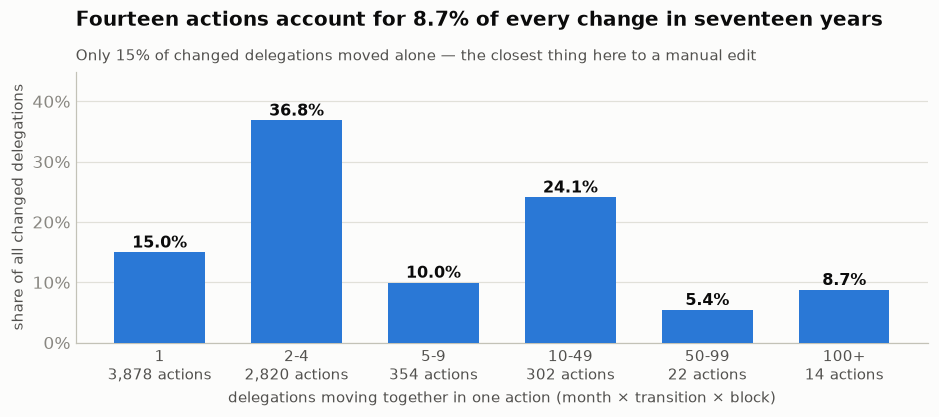

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/18_manual_vs_bulk.png')

In [20]:
LED = pd.read_parquet(ROOT / "out/analysis/delegation_changes.parquet")
CLU = pd.read_parquet(ROOT / "out/analysis/delegation_change_clusters.parquet")
SCAN = json.loads((ROOT / "out/analysis/release_scan.json").read_text(encoding="utf-8"))

bins = [1, 2, 5, 10, 50, 100, 10 ** 9]
lab = ["1", "2-4", "5-9", "10-49", "50-99", "100+"]
CLU["bucket"] = pd.cut(CLU.n_delegations, bins=bins, labels=lab, right=False)
t = CLU.groupby("bucket", observed=True).n_delegations.sum()
t = t / t.sum() * 100

fig, ax = plt.subplots(figsize=(10, 3.2))
# One hue: this is one quantity split by size, not four identities.
ax.bar(range(len(t)), t.values, color=S1, width=0.66, zorder=3)
for i, v in enumerate(t.values):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10.5, color=INK,
            fontweight="bold")
ax.set_xticks(range(len(t)))
ax.set_xticklabels([f"{b}\n{int(CLU[CLU.bucket == b].shape[0]):,} actions" for b in t.index],
                   fontsize=10, color=INK_2)
style(ax); pct(ax); ax.set_ylim(0, t.max() * 1.22)
ax.set_ylabel("share of all changed delegations", color=INK_2)
ax.set_xlabel("delegations moving together in one action (month × transition × block)",
              color=INK_2)
title(ax, "Fourteen actions account for 8.7% of every change in seventeen years",
      "Only 15% of changed delegations moved alone — the closest thing here to a manual edit")
save(fig, "18_manual_vs_bulk")

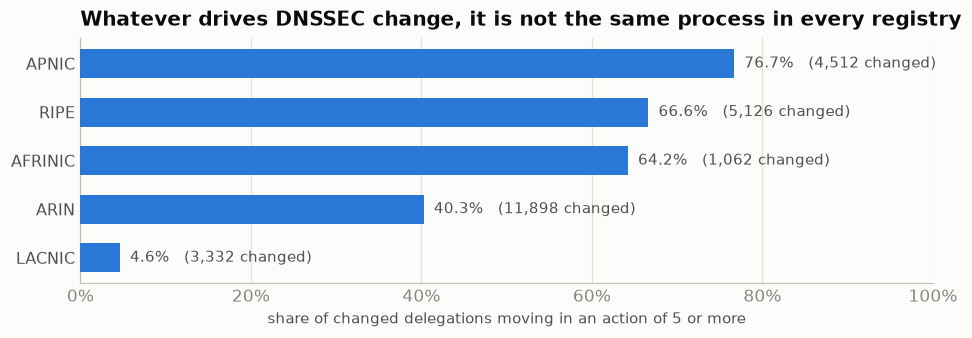

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/19_bulk_by_rir.png')

In [21]:
tot = CLU.groupby("source").n_delegations.sum()
bulk = CLU[CLU.n_delegations >= 5].groupby("source").n_delegations.sum()
pctb = (bulk / tot * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 2.9))
ax.barh(range(len(pctb)), pctb.values, height=0.6, color=S1, zorder=3)
for i, (s, v) in enumerate(pctb.items()):
    ax.text(v + 1.2, i, f"{v:.1f}%   ({int(tot[s]):,} changed)", va="center",
            fontsize=10, color=INK_2)
ax.set_yticks(range(len(pctb)))
ax.set_yticklabels([s.upper() for s in pctb.index], fontsize=10.5, color=INK_2)
style(ax, axis="x"); pct(ax, axis="x"); ax.set_xlim(0, 100)
ax.set_xlabel("share of changed delegations moving in an action of 5 or more",
              color=INK_2)
title(ax, "Whatever drives DNSSEC change, it is not the same process in every registry")
save(fig, "19_bulk_by_rir")

### 9.1 Every release against the change ledger

97% of corpus months contain a release from some project, so no ecosystem-level
control exists and no individual release is identifiable. Per project one does.
The raw comparison ranks projects by how recently they shipped; the detrended
one is the answer.

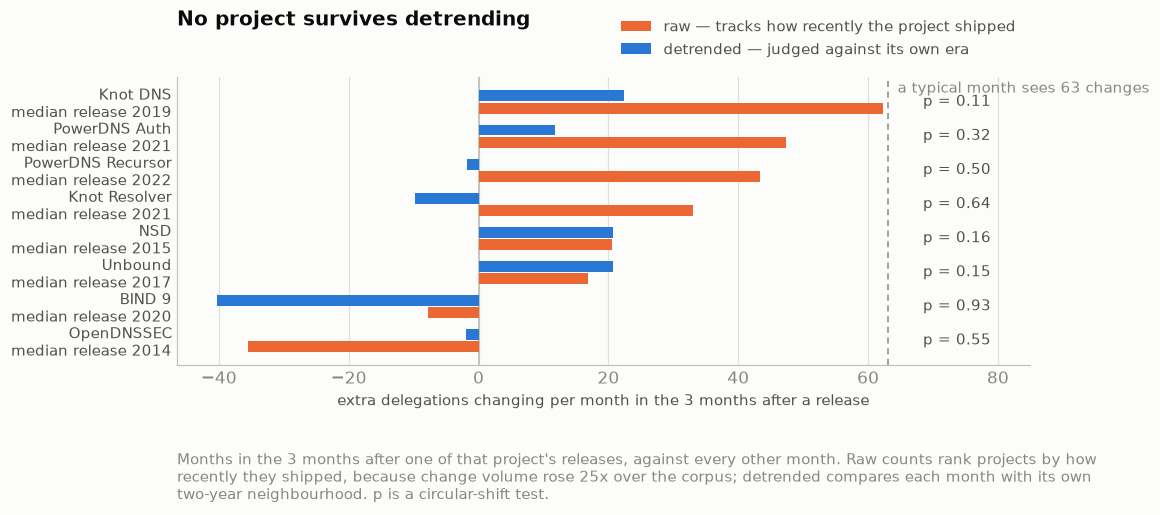

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/20_release_scan.png')

In [22]:
rows = [(p, r) for p, r in SCAN["per_project"].items() if r.get("testable")]
rows.sort(key=lambda t: t[1]["raw_difference"])
y = range(len(rows))
h = 0.36
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.barh([i - h / 2 for i in y], [r["raw_difference"] for _, r in rows], height=h - 0.04,
        color=S2, label="raw — tracks how recently the project shipped", zorder=3)
ax.barh([i + h / 2 for i in y], [r["detrended_difference"] for _, r in rows],
        height=h - 0.04, color=S1, label="detrended — judged against its own era",
        zorder=3)
# One right-hand column for the p values: keyed off each bar's own end they
# land on top of the negative bars.
lo = min(min(r["raw_difference"], r["detrended_difference"]) for _, r in rows)
hi = max(max(r["raw_difference"], r["detrended_difference"]) for _, r in rows)
label_x = hi + (hi - lo) * 0.06
for i, (_, r) in enumerate(rows):
    ax.text(label_x, i, f'p = {r["circular_shift_p"]:.2f}', va="center", fontsize=9.5,
            color=INK_2)
ax.set_xlim(lo - (hi - lo) * 0.06, label_x + (hi - lo) * 0.16)
ax.axvline(0, color=BASELINE, linewidth=1.2)
ax.set_yticks(list(y))
ax.set_yticklabels([f'{NAME[p]}\nmedian release {r["median_release_year"]}'
                    for p, r in rows], fontsize=9.5, color=INK_2)
typical = int(LED[LED.kind.isin(["sign", "rollover"])]
              .groupby("month").delegation.nunique().median())
ax.axvline(typical, color=MUTED, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.text(typical, len(rows) - 0.4, f"  a typical month sees {typical} changes",
        fontsize=9.5, color=MUTED, va="top")
ax.set_xlabel("extra delegations changing per month in the 3 months after a release",
              color=INK_2)
style(ax, axis="x")
ax.legend(frameon=False, fontsize=10, labelcolor=INK_2, loc="lower right",
          bbox_to_anchor=(1.0, 1.02), ncol=1)
ax.set_title("No project survives detrending", loc="left", color=INK,
             fontweight="bold", pad=34)
metric(ax, "Months in the 3 months after one of that project's releases, against every "
           "other month. Raw counts rank projects by how recently they shipped, because "
           "change volume rose 25x over the corpus; detrended compares each month with "
           "its own two-year neighbourhood. p is a circular-shift test.")
save(fig, "20_release_scan")

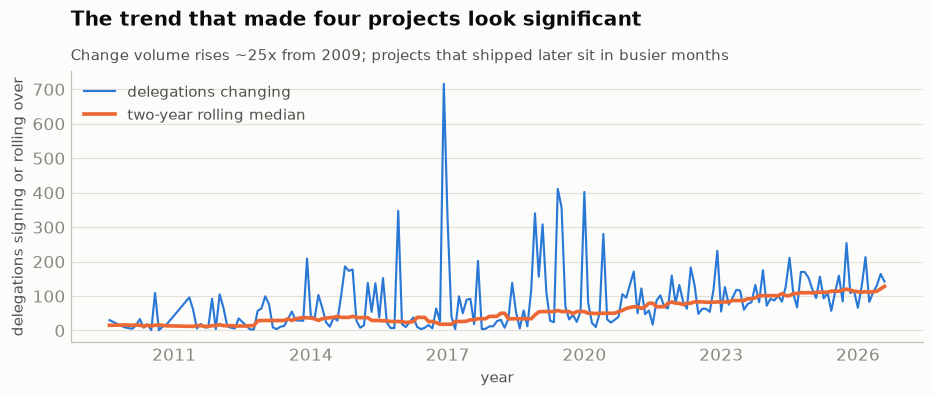

PosixPath('/mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software/21_change_trend.png')

In [23]:
per_month = (LED[LED.kind.isin(["sign", "rollover"])]
             .groupby("month").delegation.nunique().sort_index())
trend = per_month.rolling(25, center=True, min_periods=5).median()
xs = [to_year(m) for m in per_month.index]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(xs, per_month.values, color=S1, linewidth=1.4, label="delegations changing",
        zorder=3)
ax.plot(xs, trend.values, color=S2, linewidth=2.4, label="two-year rolling median",
        zorder=4)
style(ax); year_axis(ax)
ax.set_ylabel("delegations signing or rolling over", color=INK_2)
ax.set_xlabel("year", color=INK_2)
ax.legend(frameon=False, fontsize=10, labelcolor=INK_2, loc="upper left")
title(ax, "The trend that made four projects look significant",
      "Change volume rises ~25x from 2009; projects that shipped later sit in busier months")
save(fig, "21_change_trend")

## 10. One program at a time

Everything above compares projects to each other. This section gives each of the
eight its own panel, and asks one question of each: **when this program shipped,
did anything happen?**

The form is a superposed-epoch average. Every release of that program is lined up
at month zero and the surrounding two years averaged, so a release that moved
deployment would show as a step up to the right of zero. The grey band is the
same calculation on the same release pattern slid to a random point in the
corpus, two thousand times — so the band is what this program's release *rhythm*
produces against a series it has nothing to do with.

If the blue line sits inside the grey band, the program's releases are
indistinguishable from noise at that offset.

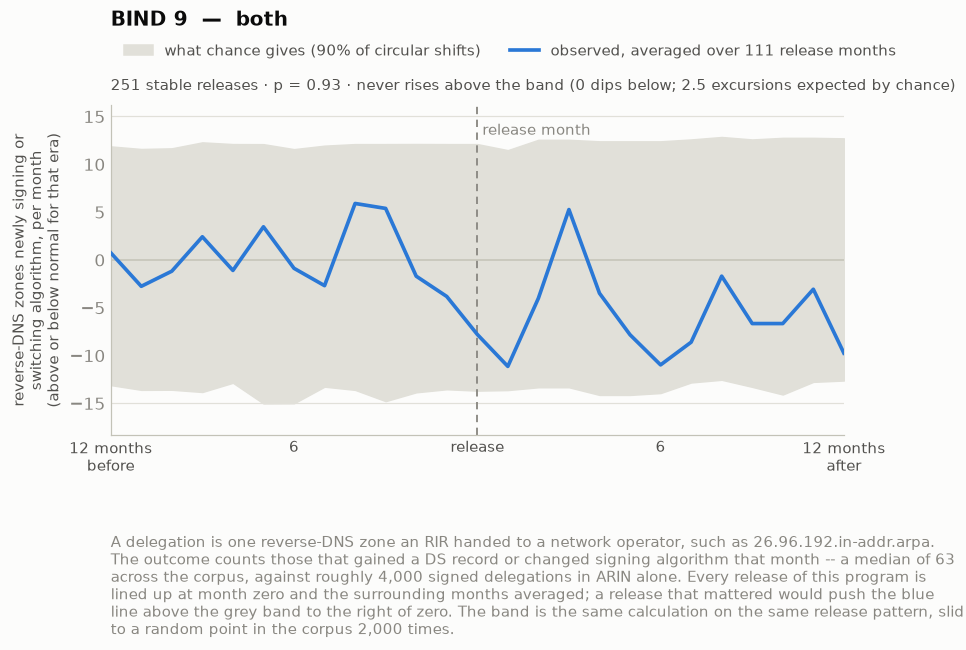

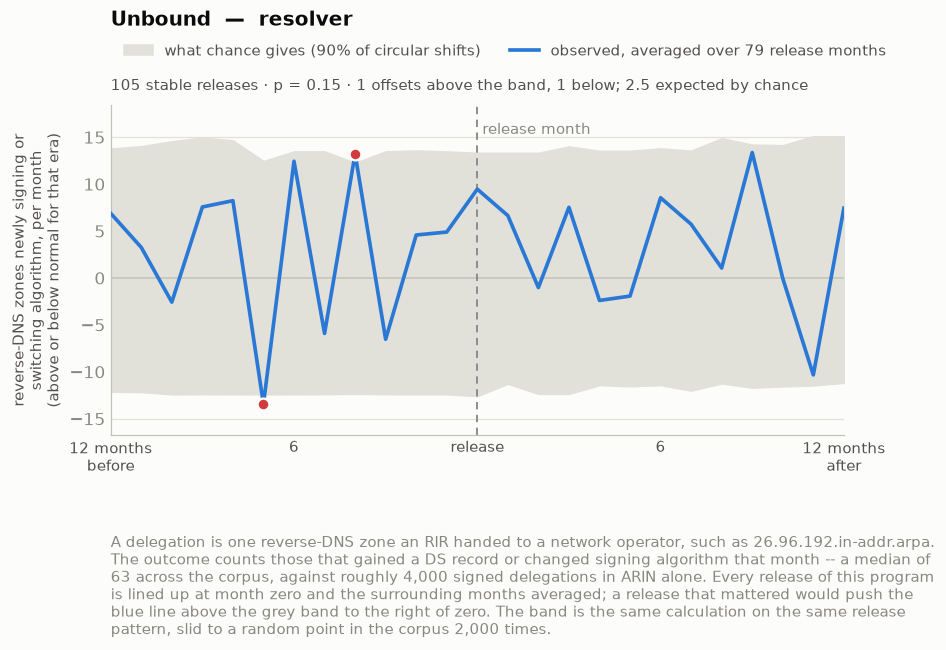

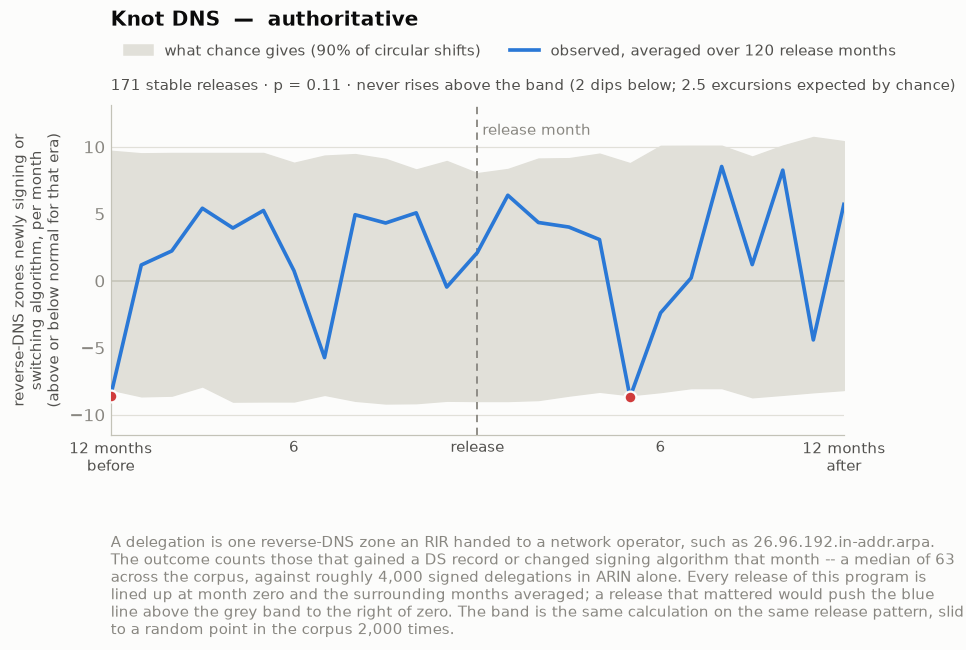

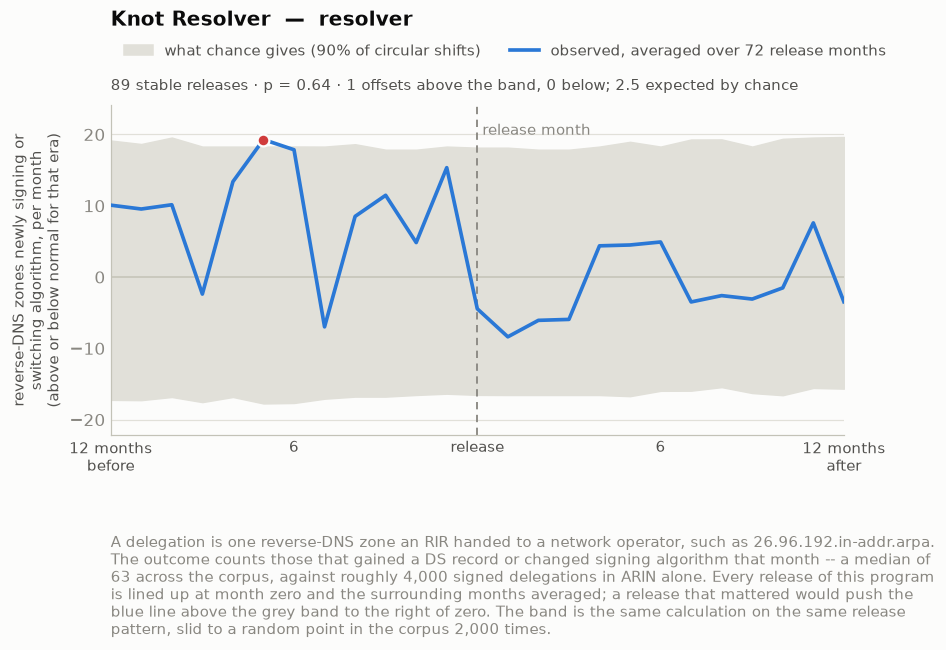

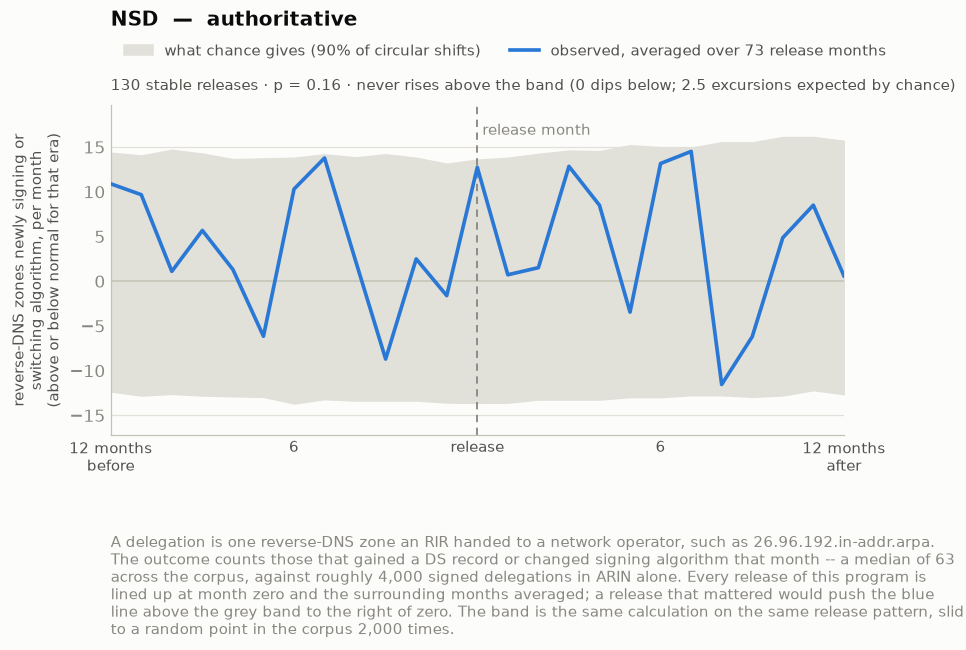

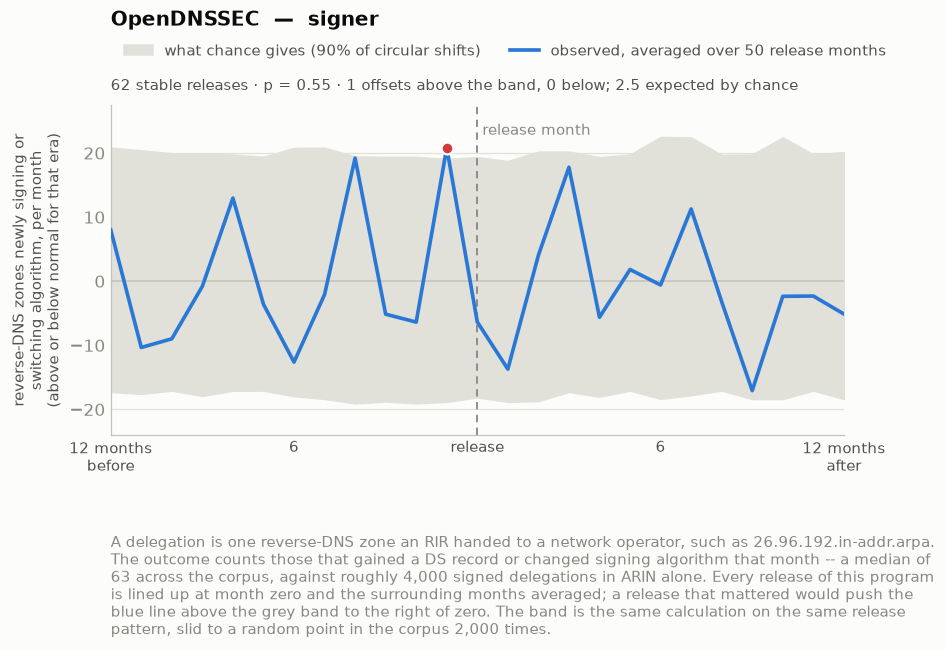

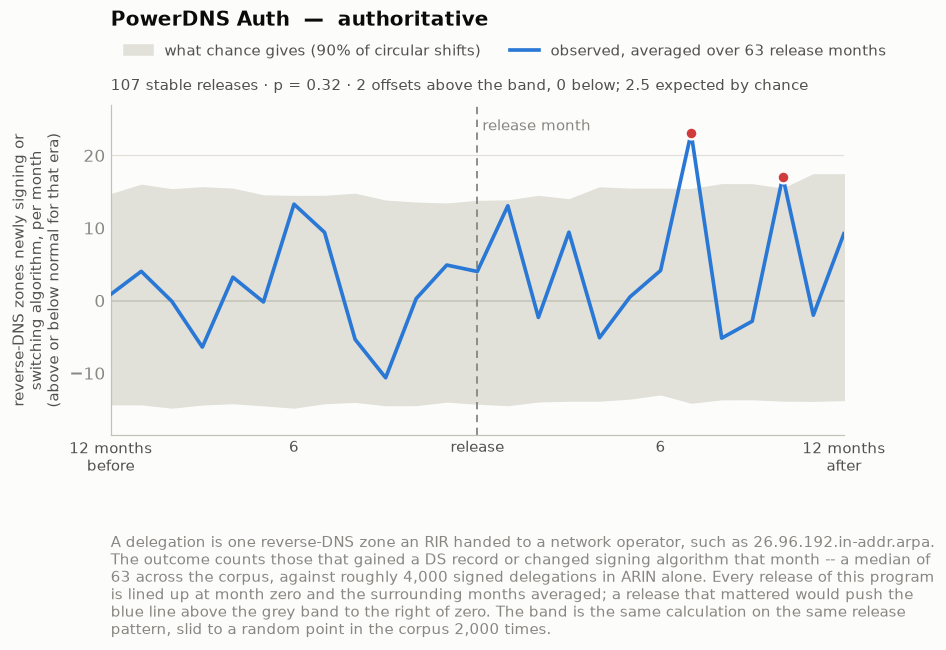

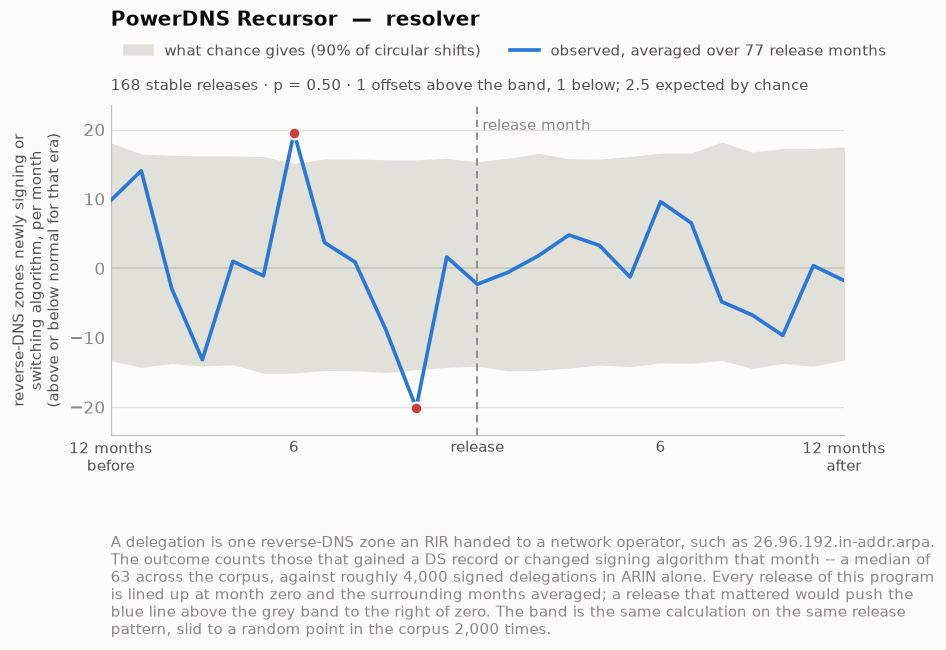

In [24]:
import numpy as np

PER_MONTH = (LED[LED.kind.isin(["sign", "rollover"])]
             .groupby("month").delegation.nunique().sort_index())
MONTHS = list(PER_MONTH.index)
IDX = {m: i for i, m in enumerate(MONTHS)}

# Detrended: each month against its own two-year neighbourhood. Raw counts rise
# ~25x over the corpus, so without this a panel measures when a project shipped.
TREND = PER_MONTH.rolling(25, center=True, min_periods=5).median()
RESID = (PER_MONTH - TREND).fillna(0.0).to_numpy()
# Centre it. A spiky series sits above its own rolling median, so the raw
# residual averages ~+30 and a zero line would read as "nothing unusual" while
# sitting nowhere near the data. Centred, zero means exactly that.
RESID = RESID - RESID.mean()

LAGS = np.arange(-12, 13)          # months either side of a release
RNG = np.random.default_rng(20260911)
N_PERM = 2000


def epoch_curve(release_idx):
    '''Mean detrended change at each offset from a release month.

    The superposed-epoch average: line every release up at month 0 and take the
    mean of what happened around them. If releases move deployment, the curve
    steps up to the right of zero.
    '''
    grid = release_idx[:, None] + LAGS[None, :]
    ok = (grid >= 0) & (grid < len(RESID))
    vals = np.where(ok, RESID[np.clip(grid, 0, len(RESID) - 1)], np.nan)
    return np.nanmean(vals, axis=0)


def null_band(release_idx, n=N_PERM):
    '''Same statistic under a circular shift of the whole schedule.

    Shifting keeps every gap between a project's releases intact and changes only
    where the schedule lands, so the band is what this release pattern would
    produce against a series it has no relationship with.
    '''
    out = np.empty((n, len(LAGS)))
    for i in range(n):
        k = RNG.integers(1, len(MONTHS))
        out[i] = epoch_curve((release_idx + k) % len(MONTHS))
    return np.nanpercentile(out, 5, axis=0), np.nanpercentile(out, 95, axis=0)


def program_panel(proj):
    '''What happened around this program's releases, against what chance gives.'''
    rel = REL[proj]["releases"]
    idx = np.array(sorted({IDX[d[:7]] for d in rel.values() if d[:7] in IDX}))
    scan = SCAN["per_project"].get(proj, {})
    if len(idx) < 5:
        return None

    obs = epoch_curve(idx)
    lo, hi = null_band(idx)

    fig, ax = plt.subplots(figsize=(8.6, 3.9))
    ax.fill_between(LAGS, lo, hi, color=GRID, zorder=1,
                    label="what chance gives (90% of circular shifts)")
    ax.axhline(0, color=BASELINE, linewidth=1, zorder=2)
    ax.axvline(0, color=MUTED, linewidth=1.2, linestyle=(0, (4, 3)), zorder=2)
    outside = (obs > hi) | (obs < lo)
    ax.plot(LAGS, obs, color=S1, linewidth=2.4, zorder=4,
            label=f"observed, averaged over {len(idx)} release months")
    if outside.any():
        ax.scatter(LAGS[outside], obs[outside], s=60, color=CRITICAL, zorder=5,
                   edgecolor=SURFACE, linewidth=1.5)

    ax.text(0, ax.get_ylim()[1], " release month", color=MUTED, fontsize=9.5,
            va="top", ha="left")
    style(ax)
    ax.set_xlim(LAGS[0], LAGS[-1])
    ax.set_xticks([-12, -6, 0, 6, 12])
    ax.set_xticklabels(["12 months\nbefore", "6", "release", "6", "12 months\nafter"],
                       fontsize=9.5, color=INK_2)
    ax.set_ylabel("reverse-DNS zones newly signing or\nswitching algorithm, per month\n"
                  "(above or below normal for that era)", color=INK_2, fontsize=9.5)
    pad = (hi.max() - lo.min()) * 0.12
    ax.set_ylim(min(lo.min(), obs.min()) - pad, max(hi.max(), obs.max()) + pad)

    role = REL[proj]["role"]
    # A 90% band puts 10% of offsets outside by construction -- 2.5 of 25 -- so
    # excursions are only worth reporting against that expectation, and only
    # upward ones would be evidence of a release driving adoption.
    above, below = int((obs > hi).sum()), int((obs < lo).sum())
    expected = round(len(LAGS) * 0.10, 1)
    if above == 0:
        verdict = (f"never rises above the band ({below} dips below; "
                   f"{expected} excursions expected by chance)")
    else:
        verdict = (f"{above} offsets above the band, {below} below; "
                   f"{expected} expected by chance")
    ax.set_title(f"{NAME[proj]}  —  {role}", loc="left", color=INK, fontweight="bold",
                 pad=52)
    ax.text(0, 1.035, f'{len(rel)} stable releases · p = '
            f'{scan.get("circular_shift_p", float("nan")):.2f} · {verdict}',
            transform=ax.transAxes, color=INK_2, fontsize=9.5, va="bottom")
    ax.legend(frameon=False, fontsize=9.5, labelcolor=INK_2, ncol=2,
              loc="lower left", bbox_to_anchor=(0, 1.10))
    metric(ax, "A delegation is one reverse-DNS zone an RIR handed to a network "
               "operator, such as 26.96.192.in-addr.arpa. The outcome counts those that "
               "gained a DS record or changed signing algorithm that month -- a median of "
               "63 across the corpus, against roughly 4,000 signed delegations in ARIN "
               "alone. Every release of this program is lined up at month zero and the "
               "surrounding months averaged; a release that mattered would push the blue "
               "line above the grey band to the right of zero. The band is the same "
               "calculation on the same release pattern, slid to a random point in the "
               "corpus 2,000 times.")
    return save(fig, f"22_program_{proj.replace('-', '_')}")


for _proj in ["bind9", "unbound", "knot", "kresd", "nsd", "opendnssec",
              "pdns-auth", "pdns-rec"]:
    program_panel(_proj)

## 8. What the figures support

**Established.** Shipping a capability does not move deployment. Onset is almost
entirely operator time (fig 1), the three clocks run RFC → code → *years* → zones
(fig 2), and four of four availability releases are followed by exactly zero
change (fig 9).

**Established.** The unit of change is the operator. Every detected jump belongs
to one of two registry operators, and the partner TLD moves in the same month in
20 of 21 cases (fig 12).

**Established.** A validator can coerce a zone, and did once: the NSEC3 iteration
tail collapsed 83% in the month after resolvers capped it, ten months before the
RFC (fig 10).

**Suggested, not established.** That default changes drive adoption. The timing
is right and vendors moved before the rise, not after (fig 8) — but no event
study detects anything (fig 9), and it rests on two observations of one
algorithm.

**Not supported.** "Software updates drive adoption rates" as a general claim.

The decisive test is blocked by coverage: both ECDSA default changes land in
2016, the forward corpus starts 2016-06 and cannot see the before-period, and the
reverse panel that spans the window lags the ecosystem by years.

In [25]:
print("Figures written to", FIGDIR.resolve())
for p in sorted(FIGDIR.glob("*.png")):
    print(f"  {p.name:34} {p.stat().st_size / 1024:6.0f} KB")

Figures written to /mnt/shared/Documents/University/year2/DNSSEC/rfc_adoption/reporting/charts/software
  01_onset_decomposition.png             51 KB
  02_three_clocks_timeline.png           80 KB
  03_pre_rfc_lead.png                   137 KB
  04_release_cadence.png                 76 KB
  05_support_matrix.png                 118 KB
  06_default_changes.png                 82 KB
  07_adoption_curves.png                 71 KB
  08_takeoff_lags.png                    89 KB
  09_event_studies.png                   80 KB
  10_nsec3_collapse.png                  79 KB
  11_nsec3_prevalence.png                60 KB
  12_portfolio_jumps.png                 96 KB
  13_cve_scope_and_rfc.png               44 KB
  14_cve_by_project.png                  53 KB
  15_cve_per_year.png                    38 KB
  16_cve_latency_and_spread.png          50 KB
  17_cve_vs_adoption.png                 59 KB
  18_manual_vs_bulk.png                  53 KB
  19_bulk_by_rir.png                     43 KB
  2